<a href="https://colab.research.google.com/github/Hana12465/cnnxtransformer-/blob/main/cnn_x_transformer_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

audit

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SOURCE = "local"
LOCAL_ROOT = "/content/drive/MyDrive/cnn_transformer/"

In [ ]:
!pip install pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 58.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import os
import glob
import pandas as pd

# Đường dẫn chính xác tới thư mục chứa dữ liệu bệnh nhân của bạn
DATA_ROOT = "/content/drive/MyDrive/physionet.org/files/i-care/2.1/training"

print("--- BẮT ĐẦU KIỂM TRA DỮ LIỆU (DATA AUDIT) ---")

# 1. Tìm tất cả các thư mục con (mỗi thư mục là 1 bệnh nhân)
patient_dirs = sorted(glob.glob(f"{DATA_ROOT}/*"))
patient_ids = [os.path.basename(d) for d in patient_dirs if os.path.isdir(d)]

print(f"Tìm thấy tổng cộng: {len(patient_ids)} thư mục bệnh nhân.")

# 2. Chạy test thử 5 bệnh nhân đầu tiên (Giống với DEBUG_LIMIT = 5 của bạn)
DEBUG_LIMIT = 5
valid_patients = []
audit_results = []

print(f"\nĐang kiểm tra chi tiết {DEBUG_LIMIT} bệnh nhân đầu tiên...")
for pid in patient_ids[:DEBUG_LIMIT]:
    # Đếm số lượng file .mat của mỗi người
    mat_files = glob.glob(f"{DATA_ROOT}/{pid}/*.mat")
    hea_files = glob.glob(f"{DATA_ROOT}/{pid}/*.hea")

    status = "Hợp lệ" if len(mat_files) > 0 else "LỖI: Trống"

    audit_results.append({
        "Patient_ID": pid,
        "So_file_MAT": len(mat_files),
        "So_file_HEA": len(hea_files),
        "Trang_thai": status
    })

# 3. Xuất kết quả ra bảng Pandas cho dễ nhìn
debug_csv = pd.DataFrame(audit_results)
pd.set_option("display.max_columns", None)
display(debug_csv)

--- BẮT ĐẦU KIỂM TRA DỮ LIỆU (DATA AUDIT) ---
Tìm thấy tổng cộng: 607 thư mục bệnh nhân.

Đang kiểm tra chi tiết 5 bệnh nhân đầu tiên...


,Patient_ID,So_file_MAT,So_file_HEA,Trang_thai
0,0284,179,179,Hợp lệ
1,0286,63,63,Hợp lệ
2,0296,12,12,Hợp lệ
3,0299,60,60,Hợp lệ
4,0303,92,92,Hợp lệ


In [ ]:
DEBUG_LIMIT = None
valid_patients = []
audit_results = []

print(f"\nĐang kiểm tra chi tiết {DEBUG_LIMIT} bệnh nhân đầu tiên...")
for pid in patient_ids[:DEBUG_LIMIT]:
    # Đếm số lượng file .mat của mỗi người
    mat_files = glob.glob(f"{DATA_ROOT}/{pid}/*.mat")
    hea_files = glob.glob(f"{DATA_ROOT}/{pid}/*.hea")

    status = "Hợp lệ" if len(mat_files) > 0 else "LỖI: Trống"

    audit_results.append({
        "Patient_ID": pid,
        "So_file_MAT": len(mat_files),
        "So_file_HEA": len(hea_files),
        "Trang_thai": status
    })

# 3. Xuất kết quả ra bảng Pandas cho dễ nhìn
debug_csv = pd.DataFrame(audit_results)
pd.set_option("display.max_columns", None)
display(debug_csv)


Đang kiểm tra chi tiết None bệnh nhân đầu tiên...


,Patient_ID,So_file_MAT,So_file_HEA,Trang_thai
0,0284,179,179,Hợp lệ
1,0286,63,63,Hợp lệ
2,0296,12,12,Hợp lệ
3,0299,60,60,Hợp lệ
4,0303,92,92,Hợp lệ
...,...,...,...,...
602,1016,0,0,LỖI: Trống
603,1017,0,0,LỖI: Trống
604,1018,0,0,LỖI: Trống
605,1019,0,0,LỖI: Trống


In [ ]:
import os
import glob
import pandas as pd
from datetime import datetime

# 1. ĐƯỜNG DẪN QUAN TRỌNG (Vui lòng kiểm tra lại cho khớp với Drive của bạn)
DATA_ROOT = "/content/drive/MyDrive/physionet.org/files/i-care/2.1/training"
OUTPUT_CSV = "/content/drive/MyDrive/cnn_transformer/patient_audit_full.csv" # Lưu thẳng lên Drive để không bị mất

print("--- BẮT ĐẦU DATA AUDIT TOÀN BỘ BỆNH NHÂN ---")

# 2. Tìm tất cả thư mục bệnh nhân
patient_dirs = sorted(glob.glob(f"{DATA_ROOT}/*"))
all_patient_ids = [os.path.basename(d) for d in patient_dirs if os.path.isdir(d)]
total_patients = len(all_patient_ids)
print(f"Tổng số bệnh nhân tìm thấy trên Drive: {total_patients}")

# 3. Cơ chế Resume (Tiếp tục nếu đã chạy dở)
audit_results = []
processed_ids = set()

if os.path.exists(OUTPUT_CSV):
    try:
        existing_df = pd.read_csv(OUTPUT_CSV)
        audit_results = existing_df.to_dict('records')
        processed_ids = set(existing_df['Patient_ID'].astype(str).tolist())
        print(f"Đã tìm thấy file lưu tạm! Có {len(processed_ids)} bệnh nhân đã được xử lý.")
    except Exception as e:
        print(f"File CSV cũ bị lỗi ({e}), sẽ bắt đầu lại từ đầu.")

# 4. Quá trình Audit với Batching
BATCH_SIZE = 20
new_count = 0

print("Bắt đầu quét dữ liệu...")
for pid in all_patient_ids:
    if pid in processed_ids:
        continue # Bỏ qua người đã làm rồi

    try:
        # Đếm file
        mat_files = glob.glob(f"{DATA_ROOT}/{pid}/*.mat")
        hea_files = glob.glob(f"{DATA_ROOT}/{pid}/*.hea")

        status = "Hợp lệ" if len(mat_files) > 0 else "LỖI: Trống"

        audit_results.append({
            "Patient_ID": pid,
            "So_file_MAT": len(mat_files),
            "So_file_HEA": len(hea_files),
            "Trang_thai": status,
            "Thoi_gian_check": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        })

        processed_ids.add(pid)
        new_count += 1

        # In tiến độ cho đỡ sốt ruột
        if new_count % 10 == 0:
            print(f"  Đã quét {len(processed_ids)} / {total_patients} bệnh nhân...")

        # Cơ chế Batching: Cứ 20 người thì lưu vào CSV 1 lần
        if new_count % BATCH_SIZE == 0:
            pd.DataFrame(audit_results).to_csv(OUTPUT_CSV, index=False)
            print(f"    -> Đã lưu tự động đợt {new_count} vào {OUTPUT_CSV}")

    except Exception as e:
        print(f"Lỗi khi xử lý bệnh nhân {pid}: {e}")

# 5. Lưu lần cuối khi hoàn thành
pd.DataFrame(audit_results).to_csv(OUTPUT_CSV, index=False)
print(f"\\n HOÀN TẤT! Đã audit thành công {len(processed_ids)}/{total_patients} bệnh nhân.")
print(f"File kết quả được lưu an toàn tại: {OUTPUT_CSV}")

# Hiển thị vài dòng kết quả
df_final = pd.DataFrame(audit_results)
display(df_final.head())

--- BẮT ĐẦU DATA AUDIT TOÀN BỘ BỆNH NHÂN ---
Tổng số bệnh nhân tìm thấy trên Drive: 607
Đã tìm thấy file lưu tạm! Có 607 bệnh nhân đã được xử lý.
Bắt đầu quét dữ liệu...
  Đã quét 617 / 607 bệnh nhân...
  Đã quét 627 / 607 bệnh nhân...
    -> Đã lưu tự động đợt 20 vào /content/drive/MyDrive/cnn_transformer/patient_audit_full.csv
  Đã quét 637 / 607 bệnh nhân...
  Đã quét 647 / 607 bệnh nhân...
    -> Đã lưu tự động đợt 40 vào /content/drive/MyDrive/cnn_transformer/patient_audit_full.csv
  Đã quét 657 / 607 bệnh nhân...
  Đã quét 667 / 607 bệnh nhân...
    -> Đã lưu tự động đợt 60 vào /content/drive/MyDrive/cnn_transformer/patient_audit_full.csv
  Đã quét 677 / 607 bệnh nhân...
  Đã quét 687 / 607 bệnh nhân...
    -> Đã lưu tự động đợt 80 vào /content/drive/MyDrive/cnn_transformer/patient_audit_full.csv
  Đã quét 697 / 607 bệnh nhân...
  Đã quét 707 / 607 bệnh nhân...
    -> Đã lưu tự động đợt 100 vào /content/drive/MyDrive/cnn_transformer/patient_audit_full.csv
  Đã quét 717 / 607 bệnh

,Patient_ID,So_file_MAT,So_file_HEA,Trang_thai,Thoi_gian_check
0,284,179,179,Hợp lệ,2026-10-02 06:18:49
1,286,63,63,Hợp lệ,2026-10-02 06:18:49
2,296,12,12,Hợp lệ,2026-10-02 06:18:49
3,299,60,60,Hợp lệ,2026-10-02 06:18:49
4,303,92,92,Hợp lệ,2026-10-02 06:18:49


In [ ]:
import pandas as pd

FULL_OUTPUT_CSV = '/content/drive/MyDrive/cnn_transformer/patient_audit_full.csv'

df = pd.read_csv(FULL_OUTPUT_CSV, dtype={"Patient_ID": str})

# 1. Xem tổng quan các loại trạng thái đang có
print("Thống kê các trạng thái (Trang_thai) trong dữ liệu:")
print(df['Trang_thai'].value_counts())
print("-" * 50)

# 2. Lọc ra những bệnh nhân bị lỗi (giả sử cột trạng thái có chứa chữ "Lỗi", "Không", hoặc "Thiếu")
# Dùng str.contains để quét các từ khóa báo lỗi phổ biến, case=False để không phân biệt hoa/thường
df_errors = df[df['Trang_thai'].str.contains('Lỗi|Thiếu|Không|Error|False', case=False, na=False)]

print(f"Tổng số bệnh nhân audit được: {len(df)}")
print(f"Số bệnh nhân audit LỖI: {len(df_errors)}")

# 3. Hiển thị chi tiết bảng lỗi
if len(df_errors) > 0:
    display(df_errors[["Patient_ID", "So_file_MAT", "So_file_HEA", "Trang_thai"]])
else:
    print("Tuyệt vời! Không có bệnh nhân nào bị lỗi.")

Thống kê các trạng thái (Trang_thai) trong dữ liệu:
Trang_thai
Hợp lệ        660
LỖI: Trống    534
Name: count, dtype: int64
--------------------------------------------------
Tổng số bệnh nhân audit được: 1194
Số bệnh nhân audit LỖI: 534


,Patient_ID,So_file_MAT,So_file_HEA,Trang_thai
325,697,0,0,LỖI: Trống
326,699,0,0,LỖI: Trống
327,700,0,0,LỖI: Trống
328,701,0,0,LỖI: Trống
329,702,0,0,LỖI: Trống
...,...,...,...,...
1189,0994,0,0,LỖI: Trống
1190,0996,0,0,LỖI: Trống
1191,0997,0,0,LỖI: Trống
1192,0998,0,0,LỖI: Trống


đang đọc nè hiếu hjhj...
đọc xong nhãn của 335 bệnh nhân òi hiếu hjhj!



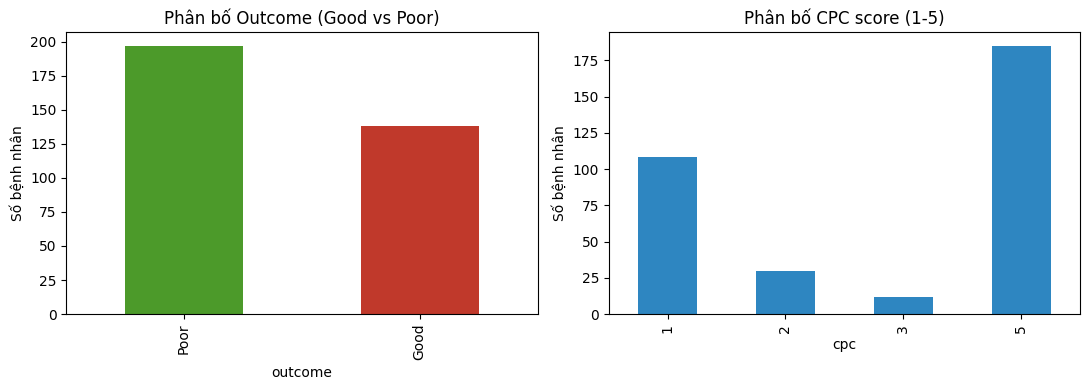


Tỷ lệ phần trăm các nhãn Outcome:
outcome
Poor    0.588
Good    0.412
Name: proportion, dtype: float64


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# 1. Trỏ vào đúng thư mục training của bạn
TRAINING_DIR = '/content/drive/MyDrive/physionet.org/files/i-care/2.1/training'

print("đang đọc nè hiếu hjhj...")

patient_labels = []

# Tìm tất cả các file .txt bên trong các thư mục con của training
txt_files = glob.glob(f'{TRAINING_DIR}/*/*.txt')

for txt_path in txt_files:
    patient_id = os.path.basename(txt_path).replace('.txt', '')
    cpc = None
    outcome = None

    # Mở từng file txt và trích xuất chữ Good/Poor, 1/2/3/4/5
    try:
        with open(txt_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('CPC:'):
                    cpc = line.split(':')[1].strip()
                elif line.startswith('Outcome:'):
                    outcome = line.split(':')[1].strip()

        patient_labels.append({
            'Patient_ID': patient_id,
            'cpc': cpc,       # Giữ chữ thường theo code cũ của bạn
            'outcome': outcome
        })
    except Exception as e:
        pass

# Tạo bảng dữ liệu nhãn
df_labels = pd.DataFrame(patient_labels)
print(f"đọc xong nhãn của {len(df_labels)} bệnh nhân òi hiếu hjhj!\n")


# --- 2. VẼ BIỂU ĐỒ MẤT CÂN BẰNG NHÃN Y NHƯ CODE CỦA BẠN ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Cột Outcome
df_labels["outcome"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C9A2A", "#C0392B"])
axes[0].set_title("Phân bố Outcome (Good vs Poor)")
axes[0].set_ylabel("Số bệnh nhân")

# Cột CPC (sort_index để xếp đúng thứ tự 1, 2, 3, 4, 5)
df_labels["cpc"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#2E86C1")
axes[1].set_title("Phân bố CPC score (1-5)")
axes[1].set_ylabel("Số bệnh nhân")

plt.tight_layout()

# Lưu ảnh về Drive như bạn muốn
os.makedirs("/content/drive/MyDrive/cnn_transformer/figures", exist_ok=True)
plt.savefig("/content/drive/MyDrive/cnn_transformer/figures/label_distribution.png", dpi=150)
plt.show()

print("\nTỷ lệ phần trăm các nhãn Outcome:")
print(df_labels["outcome"].value_counts(normalize=True).round(3))

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
!rm -rf /content/drive
drive.mount('/content/drive')

Mounted at /content/drive


tính toán thời lượng EEG nha huy

 gom thành công thời lượng của 1 bệnh nhân!


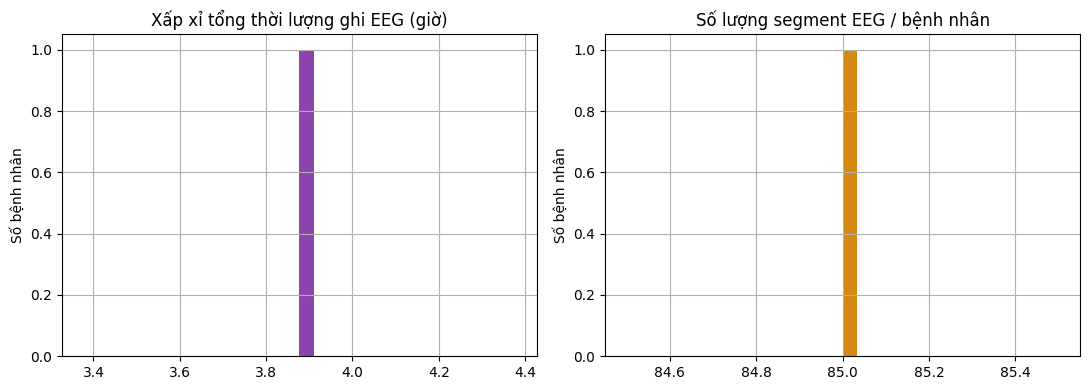


 Ảnh đã được lưu an toàn tại: /content/duration_and_segments.png
Bạn hãy nhìn sang menu thanh bên trái của Colab (biểu tượng thư mục), chuột phải vào file ảnh và chọn Download nhé!

THỐNG KÊ THỜI LƯỢNG GHI EEG (GIỜ):


,approx_duration_hours
count,1.00
mean,3.88
std,NaN
min,3.88
25%,3.88
50%,3.88
75%,3.88
max,3.88


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

TRAINING_DIR = '/content/drive/MyDrive/physionet.org/files/i-care/2.1/training'

print("tính toán thời lượng EEG nha huy")
patient_stats = []

patient_folders = glob.glob(f'{TRAINING_DIR}/*')

if len(patient_folders) == 0:
    print("huy vẫn chưa hiểu!")
else:
    for idx, folder in enumerate(patient_folders):
        if not os.path.isdir(folder):
            continue

        patient_id = os.path.basename(folder)
        hea_files = glob.glob(f'{folder}/*_EEG.hea')

        total_duration_sec = 0
        n_segments = len(hea_files)

        for hea in hea_files:
            try:
                with open(hea, 'r', encoding='utf-8') as f:
                    first_line = f.readline().strip().split()
                    if len(first_line) >= 4:
                        fs = float(first_line[2])
                        n_samples = float(first_line[3])
                        total_duration_sec += n_samples / fs
            except Exception:
                pass

        duration_hours = total_duration_sec / 3600

        patient_stats.append({
            'Patient_ID': patient_id,
            'approx_duration_hours': duration_hours,
            'n_eeg_segments': n_segments
        })

        # print tiến độ
        if (idx + 1) % 50 == 0 or (idx + 1) == len(patient_folders):
            print(f"quét xong {idx + 1}/{len(patient_folders)} bệnh nhân...")

    df = pd.DataFrame(patient_stats)
    print(f"\n gom thành công thời lượng của {len(df)} bệnh nhân!")

    # vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    df["approx_duration_hours"].hist(bins=30, ax=axes[0], color="#8E44AD")
    axes[0].set_title("Xấp xỉ tổng thời lượng ghi EEG (giờ)")
    axes[0].set_ylabel("Số bệnh nhân")

    df["n_eeg_segments"].hist(bins=30, ax=axes[1], color="#D68910")
    axes[1].set_title("Số lượng segment EEG / bệnh nhân")
    axes[1].set_ylabel("Số bệnh nhân")

    plt.tight_layout()

    # LƯU VÀO Ổ CỤC BỘ CỦA COLAB
    LOCAL_SAVE = "/content/duration_and_segments.png"
    plt.savefig(LOCAL_SAVE, dpi=150)
    plt.show()

    print(f"\n Ảnh đã được lưu an toàn tại: {LOCAL_SAVE}")
    print("Bạn hãy nhìn sang menu thanh bên trái của Colab (biểu tượng thư mục), chuột phải vào file ảnh và chọn Download nhé!")

    print("\nTHỐNG KÊ THỜI LƯỢNG GHI EEG (GIỜ):")
    display(df["approx_duration_hours"].describe().round(2))

In [ ]:
import os
import glob
import pandas as pd

TRAINING_DIR = '/content/drive/MyDrive/physionet.org/files/i-care/2.1/training'
print("Đang quét Hospital, Sampling Rate và Số kênh EEG...")

meta_stats = []
patient_folders = glob.glob(f'{TRAINING_DIR}/*')

for folder in patient_folders:
    if not os.path.isdir(folder):
        continue

    patient_id = os.path.basename(folder)
    hospital = "Unknown"
    fs = None
    n_channels = None

    # 1. Trích xuất Hospital từ file .txt
    txt_path = f"{folder}/{patient_id}.txt"
    if os.path.exists(txt_path):
        try:
            with open(txt_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.startswith('Hospital:'):
                        hospital = line.split(':')[1].strip()
        except:
            pass

    # 2. Trích xuất Sampling Rate và Số kênh từ file .hea (Chỉ cần đọc 1 file đại diện)
    hea_files = glob.glob(f'{folder}/*_EEG.hea')
    if hea_files:
        try:
            with open(hea_files[0], 'r', encoding='utf-8') as f:
                # Dòng 1 có cấu trúc: RecordName NumSignals Fs NumSamples
                first_line = f.readline().strip().split()
                if len(first_line) >= 3:
                    n_channels = int(first_line[1])
                    fs = float(first_line[2])
        except:
            pass

    meta_stats.append({
        'Patient_ID': patient_id,
        'hospital': hospital,
        'sampling_rate_hz': fs,
        'n_channels': n_channels
    })

# Tạo DataFrame
df_meta = pd.DataFrame(meta_stats)

print("Đã quét xong!\n" + "="*50)

# --- CHẠY ĐOẠN CODE KIỂM TRA CỦA BẠN ---
print("SỐ BỆNH NHÂN THEO BỆNH VIỆN:")
print(df_meta["hospital"].value_counts(), "\n")

print("CÁC MỨC SAMPLING RATE XUẤT HIỆN TRONG DATASET:")
print(df_meta["sampling_rate_hz"].value_counts(), "\n")

print("CÁC SỐ LƯỢNG KÊNH ĐIỆN CỰC (n_channels) XUẤT HIỆN:")
print(df_meta["n_channels"].value_counts())

Đang quét Hospital, Sampling Rate và Số kênh EEG...
Đã quét xong!
SỐ BỆNH NHÂN THEO BỆNH VIỆN:
hospital
Unknown    272
A          143
B           68
D           46
E           41
F           37
Name: count, dtype: int64 

CÁC MỨC SAMPLING RATE XUẤT HIỆN TRONG DATASET:
sampling_rate_hz
256.0     148
250.0      68
500.0      59
512.0      33
200.0      22
2048.0      5
Name: count, dtype: int64 

CÁC SỐ LƯỢNG KÊNH ĐIỆN CỰC (n_channels) XUẤT HIỆN:
n_channels
20.0    196
19.0    127
21.0     12
Name: count, dtype: int64


In [ ]:
import os
import glob
import pandas as pd
from collections import Counter  # Đã khai báo Counter ở đây

TRAINING_DIR = '/content/drive/MyDrive/physionet.org/files/i-care/2.1/training'
print("Đang đọc các file .hea để lấy tên chính xác của từng kênh điện cực...")

meta_stats = []
patient_folders = glob.glob(f'{TRAINING_DIR}/*')

for folder in patient_folders:
    if not os.path.isdir(folder): continue

    patient_id = os.path.basename(folder)
    channel_names = []

    hea_files = glob.glob(f'{folder}/*_EEG.hea')
    if hea_files:
        try:
            with open(hea_files[0], 'r', encoding='utf-8') as f:
                lines = f.readlines()
                first_line = lines[0].strip().split()
                if len(first_line) >= 3:
                    n_channels = int(first_line[1])
                    for i in range(1, n_channels + 1):
                        parts = lines[i].strip().split()
                        ch_name = parts[-1]
                        channel_names.append(ch_name)
        except Exception:
            pass

    meta_stats.append({
        'Patient_ID': patient_id,
        'channel_names': ",".join(channel_names) if channel_names else None
    })

df = pd.DataFrame(meta_stats)
print("Đã lấy xong tên kênh! Bắt đầu thống kê độ phủ...\n" + "="*50)

# --- THỐNG KÊ ĐỘ PHỦ KÊNH ---
channel_counter = Counter()
for chs in df["channel_names"].dropna():
    channel_counter.update(chs.split(","))

channel_coverage = (
    pd.Series(channel_counter, name="n_patients")
    .sort_values(ascending=False)
    .to_frame()
)

channel_coverage["pct_patients"] = (channel_coverage["n_patients"] / len(df) * 100).round(1)

SAVE_CSV = "/content/drive/MyDrive/cnn_transformer/channel_coverage.csv"
channel_coverage.to_csv(SAVE_CSV)

print(f"Đã lưu kết quả tại: {SAVE_CSV}")
print("DƯỚI ĐÂY LÀ BẢNG ĐỘ PHỦ CỦA CÁC KÊNH ĐIỆN CỰC:")
display(channel_coverage.head(25))

Đang đọc các file .hea để lấy tên chính xác của từng kênh điện cực...
Đã lấy xong tên kênh! Bắt đầu thống kê độ phủ...
Đã lưu kết quả tại: /content/drive/MyDrive/cnn_transformer/channel_coverage.csv
DƯỚI ĐÂY LÀ BẢNG ĐỘ PHỦ CỦA CÁC KÊNH ĐIỆN CỰC:


,n_patients,pct_patients
Fp1,335,55.2
Fp2,335,55.2
F3,335,55.2
F4,335,55.2
C3,335,55.2
C4,335,55.2
P3,335,55.2
P4,335,55.2
O1,335,55.2
O2,335,55.2


In [ ]:
from __future__ import annotations
import copy, hashlib, itertools, json, math, os, pickle, platform, random, re, shutil, sys, time, types
from collections import deque
from concurrent.futures import ProcessPoolExecutor
from dataclasses import asdict, dataclass, field, replace
from importlib import metadata
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import yaml

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!pip -q install wfdb pyyaml pyarrow tabulate

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.2 MB/s eta 0:00:00


In [ ]:
import os, re, json, math, random, hashlib, platform, subprocess, warnings, datetime
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import yaml
import wfdb
from scipy import signal as sps
from scipy.stats import norm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings("ignore", category=RuntimeWarning)

DATA_ROOT  = "/content/drive/MyDrive/physionet.org/files/i-care/2.1/training"
LOCAL_ROOT = "/content/drive/MyDrive/cnn_transformer/"

# Mọi giá trị dưới đây là LỰA CHỌN THIẾT KẾ ĐỀ XUẤT, không phải kết quả đo.
CFG = {
    "phase": "01_audit",
    "seed": 42,
    "paths": {"data_root": DATA_ROOT, "local_root": LOCAL_ROOT},
    "grid": {
        "horizon_h": 36,       # Khung 0–36 h sau ROSC. Chỉ đọc segment EEG có giờ bắt đầu (theo tên file) < 36.
        "epoch_sec": 10,       # Đoạn 10 s = 1 mẫu CNN [19, 1000] @100 Hz (Phase 2).
        "window_min": 5,       # Cửa sổ 5 phút = 1 token → E = 30 đoạn/cửa sổ, W_max = 432.
        "E_min": 6,            # Cửa sổ "có dữ liệu" khi ≥ E_min đoạn được ghi trọn (lưới khảo sát {4,6,10}).
        "W_min": 6,            # Giữ bệnh nhân khi có ≥ W_min cửa sổ có dữ liệu trong 0–36 h (lưới {3,6,12}).
        "merge_tol_sec": 1.0,  # Hai segment cách nhau ≤ 1 s coi là liên tục (Phase 2 phải dùng cùng quy tắc).
    },
    "channels": {
        "standard_19": ["Fp1","Fp2","F7","F8","F3","F4","T3","T4","C3","C4",
                        "T5","T6","P3","P4","O1","O2","Fz","Cz","Pz"],
        "known_extra": ["Fpz","Oz","F9"],                      # Kênh EEG có trong I-CARE nhưng ngoài bộ 19 → không tính là lỗi ánh xạ.
        "aliases": {"T7":"T3","T8":"T4","P7":"T5","P8":"T6"},  # Tên 10-10 tương đương; mọi lần dùng alias được log ở Cell 5.
    },
    "inclusion": {
        "K_max_missing": 4,         # Loại nếu thiếu > K kênh hiệu lực. PHẢI xác nhận lại sau khi xem phân bố ở Cell 8.
        "const_frac_missing": 0.5,  # Kênh hằng (ptp số = 0) ở ≥ 50 % đoạn lấy mẫu → coi là thiếu (mất điện cực).
    },
    "signal_sampling": {            # Lấy mẫu tín hiệu (KHÔNG dùng nhãn) để thống kê artifact
        "n_chunks": 12,             # Số khối đọc mỗi bệnh nhân, trải đều theo thời gian ghi 0–36 h.
        "chunk_sec": 60,            # Mỗi khối 60 s = 6 đoạn 10 s, nằm trọn trong 1 segment.
        "pad_sec": 10,              # Đệm 2 bên khi lọc để giảm hiệu ứng biên của filtfilt.
        "bp_low": 0.5, "bp_high": 30.0, "bp_order": 4,   # Trùng dải lọc dự kiến của Phase 2.
        "hf_band": [30.0, 45.0],    # Dải nhiễu cao tần (dưới 50/60 Hz để tránh điện lưới).
        "welch_sec": 2.0,           # nperseg của Welch khi tính hf_ratio.
        "n_workers": 8,
    },
    "artifact": {                   # Ngưỡng = phân vị trên TRAIN của fold 0 (Cell 10)
        "q_amp": 99.5,              # max|x| sau lọc 0,5–30 Hz + CAR > P99.5 → kênh lỗi biên độ.
        "q_flat": 1.0,              # std(raw đã detrend) < P1 → kênh phẳng.
        "q_hf": 99.0,               # hf_ratio > P99 → nhiễu cao tần (EMG).
        "plateau_frac_max": 0.01,   # > 1 % mẫu nằm ở min/max số → clipping (giá trị cố định vì phân vị ≈ 0).
        "max_bad_ch_frac": 0.25,    # Đoạn không hợp lệ khi > 25 % kênh hiện diện bị lỗi.
    },
    "splits": {"n_folds": 5, "inner_val_frac": 0.2, "overwrite": False},  # inner_val_frac phải bằng 1/số nguyên
    "io": {"n_workers_header": 16},
}

ROOT      = Path(LOCAL_ROOT)
AUDIT_DIR = ROOT / "data" / "audit"
CACHE_DIR = AUDIT_DIR / "_cache"
SIG_DIR   = CACHE_DIR / "signal_stats"
SPLIT_DIR = ROOT / "data" / "splits"
CFG_DIR   = ROOT / "configs"
FIG_DIR   = ROOT / "results" / "figures"
for d in [AUDIT_DIR, CACHE_DIR / "headers", SIG_DIR, SPLIT_DIR, CFG_DIR / "frozen", FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int, deterministic: bool = True) -> None:
    """Cố định seed cho random / numpy / torch (nếu có). deterministic=True bật thuật toán xác định của torch."""
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        if deterministic:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
            torch.use_deterministic_algorithms(True, warn_only=True)
            torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_seed(CFG["seed"])
cfg_txt = yaml.safe_dump(CFG, sort_keys=False, allow_unicode=True)
(CFG_DIR / "audit_phase1.yaml").write_text(cfg_txt, encoding="utf-8")
CFG_HASH = hashlib.sha256(cfg_txt.encode("utf-8")).hexdigest()
env = subprocess.run(["pip", "freeze"], capture_output=True, text=True).stdout
(AUDIT_DIR / "env.txt").write_text(
    f"python {platform.python_version()}\nwfdb {getattr(wfdb, '__version__', '?')}\n\n{env}", encoding="utf-8")
print("DATA_ROOT tồn tại:", os.path.isdir(DATA_ROOT), "| config sha256:", CFG_HASH[:12])

DATA_ROOT tồn tại: True | config sha256: 8ce4c82c3c1a


In [ ]:
H         = CFG["grid"]["horizon_h"]                  # 36
EP_SEC    = CFG["grid"]["epoch_sec"]                  # 10
H_SEC     = H * 3600                                  # 129600 s
N_EP      = H_SEC // EP_SEC                           # 12960 đoạn tối đa
E_WIN     = CFG["grid"]["window_min"] * 60 // EP_SEC  # 30 đoạn / cửa sổ
W_MAX     = N_EP // E_WIN                             # 432 cửa sổ
WIN_PER_H = 60 // CFG["grid"]["window_min"]           # 12 cửa sổ / giờ
E_MIN     = CFG["grid"]["E_min"]
W_MIN     = CFG["grid"]["W_min"]
STD19     = CFG["channels"]["standard_19"]
_STD_UP   = {c.upper(): c for c in STD19}
_ALIAS_UP = {k.upper(): v.upper() for k, v in CFG["channels"]["aliases"].items()}
assert (N_EP, E_WIN, W_MAX) == (12960, 30, 432)

def _json_default(o):
    if isinstance(o, np.integer):  return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.bool_):    return bool(o)
    if isinstance(o, (np.ndarray, set, frozenset)): return list(o)
    raise TypeError(type(o))

def _to_float(v):
    try: return float(v)
    except (TypeError, ValueError): return np.nan

def _to_bool(v):
    v = str(v).strip().lower()
    return True if v == "true" else (False if v == "false" else np.nan)

def parse_hms(s):
    """'4:07:23' hoặc '27:00:00' → số giây (giờ có thể > 24). Trả NaN nếu không đọc được."""
    m = re.match(r"^\s*(\d+):(\d{1,2}):(\d{1,2}(?:\.\d+)?)\s*$", str(s))
    return int(m[1]) * 3600 + int(m[2]) * 60 + float(m[3]) if m else np.nan

def canon_channel(name):
    """Ánh xạ tên kênh về 1 trong 19 kênh chuẩn 10–20; trả None nếu không thuộc bộ 19."""
    if name is None: return None
    n = re.sub(r"^\s*EEG\s+", "", str(name), flags=re.I).strip()
    n = re.sub(r"[-_ ]?(REF|AVG)$", "", n, flags=re.I).upper()
    return _STD_UP.get(_ALIAS_UP.get(n, n))

def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

def write_json_hashed(obj, path):
    """Ghi JSON (sort_keys) + file .sha256 bên cạnh. Trả về sha256."""
    path = Path(path)
    txt = json.dumps(obj, indent=2, sort_keys=True, ensure_ascii=False, default=_json_default)
    path.write_text(txt, encoding="utf-8")
    digest = hashlib.sha256(txt.encode("utf-8")).hexdigest()
    Path(str(path) + ".sha256").write_text(f"{digest}  {path.name}\n")
    return digest

def wilson_ci(k, n, alpha=0.05):
    """Khoảng tin cậy Wilson cho tỷ lệ k/n."""
    if n == 0: return (np.nan, np.nan)
    z = norm.ppf(1 - alpha / 2); p = k / n; den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, c - h), min(1.0, c + h))

def n_good_needed(target_lower, alpha=0.05):
    """n_Good nhỏ nhất để 0 FP/n cho giới hạn dưới Wilson ≥ target_lower."""
    z = norm.ppf(1 - alpha / 2)
    n = max(1, math.ceil(z * z * target_lower / (1 - target_lower)) - 2)
    while wilson_ci(n, n, alpha)[0] < target_lower: n += 1
    return n

def merge_intervals(iv, tol):
    """Gộp các khoảng [s, e) cách nhau ≤ tol giây. Trả (merged, số lần chồng lấn thật)."""
    merged, n_overlap = [], 0
    for s, e in sorted(iv):
        if merged and s <= merged[-1][1] + tol:
            if s < merged[-1][1] - tol: n_overlap += 1
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return merged, n_overlap

def runs_of_false(mask):
    """Các run False nằm giữa True đầu tiên và True cuối cùng: list (start, end) với end loại trừ."""
    idx = np.flatnonzero(mask)
    if idx.size < 2: return []
    sub = mask[idx[0]: idx[-1] + 1].astype(np.int8)
    d = np.diff(np.concatenate(([1], sub, [1])))
    return [(idx[0] + s, idx[0] + e) for s, e in zip(np.flatnonzero(d == -1), np.flatnonzero(d == 1))]

In [ ]:
CLIN_COLS = ["patient_id", "clinical_file", "patient_field", "hospital", "age", "sex", "rosc_min",
             "ohca", "shockable", "ttm", "outcome", "cpc"]

def parse_clinical(pid: str) -> dict:
    row = dict.fromkeys(CLIN_COLS, np.nan); row.update(patient_id=pid, clinical_file=False)
    p = Path(DATA_ROOT) / pid / f"{pid}.txt"
    if not p.exists(): return row
    kv = {}
    for line in p.read_text(errors="replace").splitlines():
        if ":" in line:
            k, v = line.split(":", 1); kv[k.strip().lower()] = v.strip()
    row.update(clinical_file=True, patient_field=kv.get("patient"), hospital=kv.get("hospital"),
               age=_to_float(kv.get("age")), sex=kv.get("sex"), rosc_min=_to_float(kv.get("rosc")),
               ohca=_to_bool(kv.get("ohca")), shockable=_to_bool(kv.get("shockable rhythm")),
               ttm=_to_float(kv.get("ttm")), outcome=kv.get("outcome"), cpc=_to_float(kv.get("cpc")))
    return row

PATIENTS = sorted(e.name for e in os.scandir(DATA_ROOT) if e.is_dir())
with ThreadPoolExecutor(CFG["io"]["n_workers_header"]) as ex:
    clin = pd.DataFrame(list(tqdm(ex.map(parse_clinical, PATIENTS), total=len(PATIENTS), desc="Clinical")),
                        columns=CLIN_COLS)

clin["label_ok"] = (clin.outcome.isin(["Good", "Poor"]) & clin.cpc.isin([1, 2, 3, 4, 5])
                    & ((clin.outcome == "Good") == (clin.cpc <= 2)))
clin["y"] = np.where(clin.outcome == "Poor", 1, np.where(clin.outcome == "Good", 0, -1))
clin["ttm_group"] = np.select([clin.ttm == 33, clin.ttm == 36], ["33", "36"], default="none")

print(f"Thư mục bệnh nhân: {len(PATIENTS)} (kỳ vọng 607)")
print("Thiếu file lâm sàng:", int((~clin.clinical_file).sum()),
      "| nhãn không hợp lệ / outcome–CPC lệch:", int((clin.clinical_file & ~clin.label_ok).sum()))
mism = clin[clin.clinical_file & (clin.patient_field.astype(str) != clin.patient_id)]
print("Trường 'Patient' khác tên thư mục:", len(mism))
display(pd.crosstab(clin.hospital, clin.outcome, margins=True))

Clinical:   0%|          | 0/607 [00:00<?, ?it/s]

Thư mục bệnh nhân: 607 (kỳ vọng 607)
Thiếu file lâm sàng: 272 | nhãn không hợp lệ / outcome–CPC lệch: 0
Trường 'Patient' khác tên thư mục: 0


outcome,Good,Poor,All
hospital,,,
A,71,72,143
B,24,44,68
D,15,31,46
E,8,33,41
F,20,17,37
All,138,197,335


In [ ]:
EEG_HEA  = re.compile(r"^(?P<pid>.+)_(?P<seg>\d+)_(?P<hour>\d+)_EEG\.hea$")
SEG_COLS = ["patient_id", "record", "seg", "hour_file", "fs", "n_samples", "n_sig", "sig_names",
            "units", "fmt", "start_sec", "end_sec_hdr", "utility_freq", "error"]

def _comments_to_dict(comments):
    out = {}
    for c in comments or []:
        if ":" in c:
            k, v = c.split(":", 1); out[k.strip().lower()] = v.strip()
    return out

def inventory_patient(pid: str) -> dict:
    """Đọc header mọi segment EEG có giờ bắt đầu (tên file) < horizon_h. Cache JSON theo bệnh nhân."""
    cache = CACHE_DIR / "headers" / f"{pid}.json"
    if cache.exists():
        return json.loads(cache.read_text())
    pdir = Path(DATA_ROOT) / pid
    try:
        files = sorted(f for f in os.listdir(pdir) if EEG_HEA.match(f))
    except OSError as e:
        return {"patient_id": pid, "n_eeg_files_total": 0, "rows": [], "list_error": repr(e)}
    rows = []
    for f in files:
        m = EEG_HEA.match(f); hour = int(m["hour"])
        if hour >= H: continue
        rec = f[:-4]
        row = dict.fromkeys(SEG_COLS, np.nan)
        row.update(patient_id=pid, record=rec, seg=int(m["seg"]), hour_file=hour, error="")
        try:
            hd = wfdb.rdheader(str(pdir / rec))
            com = _comments_to_dict(hd.comments)
            row.update(fs=float(hd.fs), n_samples=int(hd.sig_len), n_sig=int(hd.n_sig),
                       sig_names="|".join(hd.sig_name), units="|".join(map(str, hd.units or [])),
                       fmt="|".join(map(str, hd.fmt or [])),
                       start_sec=parse_hms(com.get("start time", "")),
                       end_sec_hdr=parse_hms(com.get("end time", "")),
                       utility_freq=_to_float(com.get("utility frequency")))
        except Exception as e:
            row["error"] = repr(e)
        rows.append(row)
    out = {"patient_id": pid, "n_eeg_files_total": len(files), "rows": rows}
    cache.write_text(json.dumps(out, default=_json_default))
    return out

with ThreadPoolExecutor(CFG["io"]["n_workers_header"]) as ex:
    inv = list(tqdm(ex.map(inventory_patient, PATIENTS), total=len(PATIENTS), desc="Header EEG"))

seg_df = pd.DataFrame([r for x in inv for r in x["rows"]], columns=SEG_COLS)
seg_df["error"] = seg_df["error"].fillna("")
seg_df["end_sec"] = seg_df.start_sec + seg_df.n_samples / seg_df.fs
inv_df = pd.DataFrame({"patient_id": [x["patient_id"] for x in inv],
                       "n_eeg_files_total": [x["n_eeg_files_total"] for x in inv],
                       "list_error": [x.get("list_error", "") for x in inv]})
seg_df.to_csv(AUDIT_DIR / "audit_segments.csv", index=False)

QC_HDR = {
    "n_segments_0_36h": len(seg_df),
    "n_header_errors": int((seg_df.error != "").sum()),
    "n_missing_start_time": int(((seg_df.error == "") & ~np.isfinite(seg_df.start_sec)).sum()),
    "n_hour_file_mismatch": int((np.isfinite(seg_df.start_sec)
                                 & (np.floor(seg_df.start_sec / 3600) != seg_df.hour_file)).sum()),
    "n_end_time_mismatch_gt2s": int(((seg_df.end_sec - seg_df.end_sec_hdr).abs() > 2).sum()),
    "n_patients_list_error": int((inv_df.list_error != "").sum()),
}
print(QC_HDR)
print("Phân bố fs (Hz):"); display(seg_df.fs.value_counts().rename("n_segments"))
print("Tần số điện lưới:"); display(seg_df.utility_freq.value_counts(dropna=False).rename("n_segments"))

Header EEG:   0%|          | 0/607 [00:00<?, ?it/s]

{'n_segments_0_36h': 6950, 'n_header_errors': 0, 'n_missing_start_time': 0, 'n_hour_file_mismatch': 0, 'n_end_time_mismatch_gt2s': 0, 'n_patients_list_error': 0}
Phân bố fs (Hz):


,n_segments
fs,
256.0,3164
500.0,1481
250.0,1224
512.0,617
200.0,390
2048.0,74


Tần số điện lưới:


,n_segments
utility_freq,
50.0,4735
60.0,2215


In [ ]:
seg_ok = seg_df[(seg_df.error == "") & np.isfinite(seg_df.start_sec) & (seg_df.fs > 0)
                & (seg_df.start_sec < H_SEC)].copy()
seg_ok["dur_in_h"] = (np.minimum(seg_ok.end_sec, H_SEC) - np.maximum(seg_ok.start_sec, 0)).clip(lower=0)
seg_ok["std_set"] = seg_ok.sig_names.map(
    lambda s: frozenset(c for c in (canon_channel(n) for n in str(s).split("|")) if c))

# Log tên kênh: dùng alias / không ánh xạ được
names = seg_ok[["patient_id", "sig_names"]].copy()
names["name"] = names.sig_names.str.split("|")
names = names.explode("name")
names["name"] = names.name.str.strip()
names["canon"] = names.name.map(canon_channel)
names = names.merge(clin[["patient_id", "hospital"]], on="patient_id", how="left")
alias_used = names[names.canon.notna() & (names.name.str.upper() != names.canon.str.upper())]
unmapped = names[names.canon.isna() & ~names.name.isin(CFG["channels"]["known_extra"])]
alias_tab = alias_used.groupby(["name", "canon"]).patient_id.nunique().rename("n_patients").reset_index()
unmapped_tab = unmapped.groupby(["hospital", "name"]).patient_id.nunique().rename("n_patients").reset_index()
print("Alias đã dùng:"); display(alias_tab)
print("Tên kênh trong file EEG không thuộc 19 kênh + known_extra:"); display(unmapped_tab)

# Kênh theo bệnh nhân: header_present = có mặt trong MỌI segment 0–36 h (kênh chỉ có một phần → coi là thiếu)
ch_rows = []
for pid, g in seg_ok.groupby("patient_id"):
    g = g[g.dur_in_h > 0]; tot = g.dur_in_h.sum()
    for ch in STD19:
        has = g.std_set.map(lambda S: ch in S)
        frac = float(g.dur_in_h[has].sum() / tot) if tot > 0 else 0.0
        ch_rows.append((pid, ch, frac, bool(len(g) > 0 and has.all())))
chan_df = pd.DataFrame(ch_rows, columns=["patient_id", "ch", "dur_frac_present", "header_present"])
chan_df["partial"] = (chan_df.dur_frac_present > 0) & ~chan_df.header_present

cm = chan_df.merge(clin[["patient_id", "hospital"]], on="patient_id", how="left")
cm["missing"] = ~cm.header_present
tab_ch_hosp = cm.pivot_table(index="hospital", columns="ch", values="missing", aggfunc="mean")[STD19].round(3)
print("Tỷ lệ bệnh nhân THIẾU kênh (mức header) theo bệnh viện:"); display(tab_ch_hosp)
print("Số cặp (bệnh nhân, kênh) chỉ có một phần thời gian:", int(chan_df.partial.sum()))

Alias đã dùng:


,name,canon,n_patients


Tên kênh trong file EEG không thuộc 19 kênh + known_extra:


,hospital,name,n_patients


Tỷ lệ bệnh nhân THIẾU kênh (mức header) theo bệnh viện:


ch,Fp1,Fp2,F7,F8,F3,F4,T3,T4,C3,C4,T5,T6,P3,P4,O1,O2,Fz,Cz,Pz
hospital,,,,,,,,,,,,,,,,,,,
A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Số cặp (bệnh nhân, kênh) chỉ có một phần thời gian: 0


In [ ]:
# ==== CELL 6 — Phủ thời gian 0–36 h trên lưới tuyệt đối từ ROSC + gaps ====
# Đoạn k phủ [10k, 10k+10) s. Đoạn "được ghi" khi nằm TRỌN trong vùng có EEG (sau khi gộp segment).
# Cửa sổ w "có dữ liệu" khi ≥ E_min đoạn được ghi. Gap = chuỗi cửa sổ không có dữ liệu nằm giữa hai cửa sổ có dữ liệu.
TOL = CFG["grid"]["merge_tol_sec"]
cov_rows, gap_rows, hourly = [], [], {}
for pid, g in tqdm(seg_ok.groupby("patient_id"), desc="Coverage"):
    iv = [(max(s, 0.0), min(e, H_SEC)) for s, e in zip(g.start_sec, g.end_sec) if min(e, H_SEC) > max(s, 0.0)]
    merged, n_overlap = merge_intervals(iv, TOL)
    rec = np.zeros(N_EP, dtype=bool)
    for s, e in merged:
        k0, k1 = math.ceil(s / EP_SEC - 1e-9), math.floor(e / EP_SEC + 1e-9)
        if k1 > k0: rec[k0:k1] = True
    n_rec_w = rec.reshape(W_MAX, E_WIN).sum(1)
    win = n_rec_w >= E_MIN
    idx = np.flatnonzero(rec)
    ep_gaps, w_gaps = runs_of_false(rec), runs_of_false(win)
    for w0, w1 in w_gaps:
        gap_rows.append({"patient_id": pid, "gap_start_h": w0 / WIN_PER_H, "gap_end_h": w1 / WIN_PER_H,
                         "gap_len_h": (w1 - w0) / WIN_PER_H, "hour_bin": int(w0 // WIN_PER_H)})
    hourly[pid] = win.reshape(H, WIN_PER_H).any(1).astype(int)
    cov_rows.append({
        "patient_id": pid, "n_seg_0_36": len(g), "n_seg_overlaps": n_overlap,
        "first_eeg_h": idx[0] * EP_SEC / 3600 if idx.size else np.nan,
        "last_eeg_h": (idx[-1] + 1) * EP_SEC / 3600 if idx.size else np.nan,
        "rec_hours": rec.sum() * EP_SEC / 3600,
        "n_rec_epochs": int(rec.sum()), "n_windows_present": int(win.sum()),
        "n_epoch_gaps": len(ep_gaps),
        "epoch_gap_total_h": sum(e - s for s, e in ep_gaps) * EP_SEC / 3600,
        "n_window_gaps": len(w_gaps),
        "max_window_gap_h": max(((e - s) / WIN_PER_H for s, e in w_gaps), default=0.0),
        "n_hours_with_data": int(hourly[pid].sum()),
    })

cov_df  = pd.DataFrame(cov_rows)
gaps_df = pd.DataFrame(gap_rows, columns=["patient_id", "gap_start_h", "gap_end_h", "gap_len_h", "hour_bin"])
hourly_df = pd.DataFrame.from_dict(hourly, orient="index", columns=[f"h{h:02d}" for h in range(H)])
hourly_df.index.name = "patient_id"
gaps_df.to_csv(AUDIT_DIR / "audit_gaps.csv", index=False)
hourly_df.to_csv(AUDIT_DIR / "audit_hourly_coverage.csv")
print("Bệnh nhân có EEG trong 0–36 h:", len(cov_df))
display(cov_df[["first_eeg_h", "rec_hours", "n_windows_present", "n_window_gaps", "max_window_gap_h"]]
        .describe(percentiles=[.25, .5, .75, .9]).round(2))

Coverage:   0%|          | 0/308 [00:00<?, ?it/s]

Bệnh nhân có EEG trong 0–36 h: 308


,first_eeg_h,rec_hours,n_windows_present,n_window_gaps,max_window_gap_h
count,308.00,308.00,308.00,308.00,308.00
mean,13.11,20.45,245.98,0.19,0.18
std,7.92,8.42,101.10,0.53,0.92
min,0.34,0.68,9.00,0.00,0.00
25%,5.91,14.88,179.25,0.00,0.00
50%,12.14,20.41,245.50,0.00,0.00
75%,18.96,27.71,333.25,0.00,0.00
90%,24.12,31.20,375.30,1.00,0.17
max,35.32,35.60,428.00,3.00,10.83


In [ ]:
# ==== CELL 7 — Thống kê tín hiệu trên khối lấy mẫu (KHÔNG dùng nhãn). Cache theo bệnh nhân, chạy lại được ====
# Mỗi (đoạn 10 s, kênh): ptp_dig (biên độ số), plateau_frac (clipping), std_raw (raw detrend),
# hf_ratio (P30–45 / P0.5–30), max_abs_bp & std_bp (sau lọc 0,5–30 Hz + CAR trên kênh không hằng).
SS = CFG["signal_sampling"]
CHUNK_EP = SS["chunk_sec"] // EP_SEC
_SOS = {}
def _sos(fs):
    if fs not in _SOS:
        _SOS[fs] = sps.butter(SS["bp_order"], [SS["bp_low"], SS["bp_high"]], btype="bandpass", fs=fs, output="sos")
    return _SOS[fs]

SEG_BY_PID = {pid: g.sort_values("start_sec") for pid, g in seg_ok.groupby("patient_id")}
HP = chan_df[chan_df.header_present].groupby("patient_id").ch.apply(set).to_dict()

def plan_chunks(g):
    """Ứng viên = mọi khối 6 đoạn nằm trọn trong 1 segment (trong 0–36 h); chọn n_chunks khối trải đều theo thời gian."""
    cands = []
    for r in g.itertuples():
        s, e = max(r.start_sec, 0.0), min(r.end_sec, H_SEC)
        k0, k1 = math.ceil(s / EP_SEC - 1e-9), math.floor(e / EP_SEC + 1e-9)
        for k in range(k0, k1 - CHUNK_EP + 1, CHUNK_EP):
            cands.append((r.record, r.start_sec, r.fs, int(r.n_samples), k))
    if not cands: return []
    cands.sort(key=lambda c: c[4])
    pick = np.unique(np.linspace(0, len(cands) - 1, min(SS["n_chunks"], len(cands))).round().astype(int))
    return [cands[i] for i in pick]

def chunk_stats(pid, rec_name, start_sec, fs, n_samples, k, hp_set):
    L = int(round(EP_SEC * fs)); pad = int(round(SS["pad_sec"] * fs))
    i0 = int(round((k * EP_SEC - start_sec) * fs))
    i0 = max(0, min(i0, n_samples - CHUNK_EP * L))          # chỉnh lệch làm tròn ≤ 1 mẫu
    a, b = max(0, i0 - pad), min(n_samples, i0 + CHUNK_EP * L + pad)
    r = wfdb.rdrecord(str(Path(DATA_ROOT) / pid / rec_name), sampfrom=a, sampto=b, physical=False)
    d = np.asarray(r.d_signal, dtype=np.int64)
    gain, base = np.asarray(r.adc_gain, float), np.asarray(r.baseline, float)
    idx = {}
    for i, n in enumerate(r.sig_name):
        c = canon_channel(n)
        if c and c in hp_set and c not in idx: idx[c] = i
    chans = [c for c in STD19 if c in idx]
    if not chans: raise ValueError("không có kênh chuẩn header_present")
    cols = [idx[c] for c in chans]
    d19 = d[:, cols]
    phys = (d19 - base[cols]) / gain[cols]
    off = i0 - a
    core = slice(off, off + CHUNK_EP * L)
    nonconst = d19[core].max(0) != d19[core].min(0)
    xc = None
    if fs > 2 * SS["bp_high"]:
        xf = sps.sosfiltfilt(_sos(fs), phys - phys.mean(0, keepdims=True), axis=0)
        xc = xf - (xf[:, nonconst].mean(1, keepdims=True) if nonconst.any() else 0.0)
    hf_ok = fs > 2 * SS["hf_band"][1]
    rows = []
    for e in range(CHUNK_EP):
        sl = slice(off + e * L, off + (e + 1) * L)
        dd = d19[sl]; raw = sps.detrend(phys[sl], axis=0)
        mx, mn = dd.max(0), dd.min(0); ptp = mx - mn
        plateau = np.where(ptp == 0, 1.0, ((dd == mx).sum(0) + (dd == mn).sum(0)) / dd.shape[0])
        if hf_ok:
            f, P = sps.welch(raw, fs=fs, nperseg=int(round(SS["welch_sec"] * fs)), axis=0)
            hb = (f >= SS["hf_band"][0]) & (f < SS["hf_band"][1])
            lb = (f >= SS["bp_low"]) & (f < SS["bp_high"])
            hf = P[hb].sum(0) / np.maximum(P[lb].sum(0), 1e-30)
        else:
            hf = np.full(len(chans), np.nan)
        if xc is not None:
            xe = xc[sl]; max_abs, std_bp = np.abs(xe).max(0), xe.std(0)
        else:
            max_abs = std_bp = np.full(len(chans), np.nan)
        std_raw = raw.std(0)
        for j, c in enumerate(chans):
            rows.append({"patient_id": pid, "record": rec_name, "epoch_k": k + e,
                         "hour": int((k + e) * EP_SEC // 3600), "ch": c, "fs": fs,
                         "ptp_dig": int(ptp[j]), "plateau_frac": float(plateau[j]), "std_raw": float(std_raw[j]),
                         "hf_ratio": float(hf[j]), "max_abs_bp": float(max_abs[j]), "std_bp": float(std_bp[j])})
    return rows

def stats_patient(pid):
    st_path = SIG_DIR / f"{pid}.status.json"
    if st_path.exists(): return json.loads(st_path.read_text())
    plan = plan_chunks(SEG_BY_PID[pid]); hp_set = HP.get(pid, set())
    rows, n_ok, errs = [], 0, []
    for c in plan:
        for attempt in range(2):                     # thử lại 1 lần nếu Drive lỗi tạm thời
            try:
                rows += chunk_stats(pid, *c, hp_set); n_ok += 1; break
            except Exception as e:
                if attempt == 1: errs.append(f"{c[0]}@k{c[4]}: {e!r}")
    if rows: pd.DataFrame(rows).to_parquet(SIG_DIR / f"{pid}.parquet", index=False)
    status = {"patient_id": pid, "n_chunks_planned": len(plan), "n_chunks_ok": n_ok,
              "n_chunk_errors": len(errs), "errors": errs[:5]}
    st_path.write_text(json.dumps(status))
    return status

PIDS_SIG = sorted(SEG_BY_PID)
with ThreadPoolExecutor(SS["n_workers"]) as ex:
    sig_status = pd.DataFrame(list(tqdm(ex.map(stats_patient, PIDS_SIG), total=len(PIDS_SIG), desc="Signal stats")))
print("Khối đọc OK:", int(sig_status.n_chunks_ok.sum()), "/", int(sig_status.n_chunks_planned.sum()),
      "| bệnh nhân không đọc được khối nào:", int((sig_status.n_chunks_ok == 0).sum()))
display(sig_status[sig_status.n_chunk_errors > 0].head(10))

Signal stats:   0%|          | 0/308 [00:00<?, ?it/s]

Khối đọc OK: 3696 / 3696 | bệnh nhân không đọc được khối nào: 0


,patient_id,n_chunks_planned,n_chunks_ok,n_chunk_errors,errors


In [ ]:
# ==== CELL 8 — Mặt nạ kênh hiệu lực + tiêu chí loại. XEM BẢNG PHÂN BỐ RỒI MỚI CHỐT K ====
files = sorted(SIG_DIR.glob("*.parquet"))
sig_all = pd.concat([pd.read_parquet(f) for f in tqdm(files, desc="Load stats")], ignore_index=True)

const = (sig_all.assign(is_const=sig_all.ptp_dig == 0)
         .groupby(["patient_id", "ch"]).is_const.mean().rename("const_frac").reset_index())
chan_df = chan_df.drop(columns=["const_frac", "eff_present"], errors="ignore") \
                 .merge(const, on=["patient_id", "ch"], how="left")
chan_df["eff_present"] = chan_df.header_present & (chan_df.const_frac.fillna(1.0) < CFG["inclusion"]["const_frac_missing"])
chan_df.to_csv(AUDIT_DIR / "audit_channels.csv", index=False)

mask_df = (chan_df.pivot(index="patient_id", columns="ch", values="eff_present")[STD19]
           .apply(lambda r: "".join("1" if bool(v) else "0" for v in r), axis=1)
           .rename("channel_mask_eff").reset_index())
mask_df["n_missing_eff"] = 19 - mask_df.channel_mask_eff.str.count("1")

pat = (clin.merge(inv_df, on="patient_id", how="left")
           .merge(cov_df, on="patient_id", how="left")
           .merge(sig_status[["patient_id", "n_chunks_planned", "n_chunks_ok", "n_chunk_errors"]],
                  on="patient_id", how="left")
           .merge(mask_df, on="patient_id", how="left"))
for c in ["n_seg_0_36", "n_windows_present", "n_chunks_ok"]:
    pat[c] = pat[c].fillna(0).astype(int)
pat["n_missing_eff"] = pat.n_missing_eff.fillna(19).astype(int)

pre = pat[pat.label_ok & (pat.n_seg_0_36 > 0) & (pat.n_chunks_ok > 0)]
print("Phân bố số kênh thiếu hiệu lực theo bệnh viện (trước khi áp K):")
display(pd.crosstab(pre.hospital, pre.n_missing_eff, margins=True))
sens_K = pd.DataFrame([{"K": k,
                        "n_kept": int(((pre.n_missing_eff <= k) & (pre.n_windows_present >= W_MIN)).sum()),
                        "n_good": int(((pre.n_missing_eff <= k) & (pre.n_windows_present >= W_MIN) & (pre.outcome == "Good")).sum()),
                        "n_poor": int(((pre.n_missing_eff <= k) & (pre.n_windows_present >= W_MIN) & (pre.outcome == "Poor")).sum())}
                       for k in range(0, 9)])
print("Độ nhạy cỡ mẫu theo K:"); display(sens_K)

K = CFG["inclusion"]["K_max_missing"]
def _reason(r):
    if not r.label_ok:                   return "no_clinical_or_invalid_label"
    if r.n_seg_0_36 == 0:                return "no_eeg_0_36h"
    if r.n_chunks_ok == 0:               return "signal_unreadable"
    if r.n_missing_eff > K:              return f"missing_channels_gt_{K}"
    if r.n_windows_present < W_MIN:      return f"windows_present_lt_{W_MIN}"
    return ""
pat["exclusion_reason"] = pat.apply(_reason, axis=1)
pat["included"] = pat.exclusion_reason == ""
pat[["patient_id", "hospital", "outcome", "cpc", "included", "exclusion_reason", "channel_mask_eff"]] \
    .to_csv(AUDIT_DIR / "inclusion_list.csv", index=False)
print(f"K = {K} → giữ {int(pat.included.sum())}/{len(pat)}")
display(pd.crosstab(pat.hospital.fillna("?"), pat.exclusion_reason.replace("", "INCLUDED"), margins=True))

Load stats:   0%|          | 0/308 [00:00<?, ?it/s]

Phân bố số kênh thiếu hiệu lực theo bệnh viện (trước khi áp K):


n_missing_eff,0,1,3,4,5,7,8,10,19,All
hospital,,,,,,,,,,
A,112,12,2,4,2,2,1,1,2,138
B,57,0,0,0,0,0,0,0,0,57
D,31,0,0,0,0,0,0,0,9,40
E,36,1,0,0,0,0,0,0,0,37
F,34,0,0,0,0,0,0,0,2,36
All,270,13,2,4,2,2,1,1,13,308


Độ nhạy cỡ mẫu theo K:


,K,n_kept,n_good,n_poor
0,0,270,111,159
1,1,283,118,165
2,2,283,118,165
3,3,285,119,166
4,4,289,121,168
5,5,291,122,169
6,6,291,122,169
7,7,293,123,170
8,8,294,124,170


K = 4 → giữ 289/607


exclusion_reason,INCLUDED,missing_channels_gt_4,no_clinical_or_invalid_label,no_eeg_0_36h,All
hospital,,,,,
?,0,0,272,0,272
A,130,8,0,5,143
B,57,0,0,11,68
D,31,9,0,6,46
E,37,0,0,4,41
F,34,2,0,1,37
All,289,19,272,27,607


In [ ]:
# ==== CELL 9 — 5-fold phân tầng (outcome × bệnh viện) + inner-val, theo patient_id; ghi folds.json + sha256 ====
def make_folds(df, n_folds, inner_val_frac, seed):
    """Gán vòng (round-robin) trong từng tầng sau khi xáo trộn có seed. inner-val lấy 1/step mỗi tầng của train."""
    rng = np.random.default_rng(seed)
    df = df.sort_values("patient_id")
    strata = df.outcome.astype(str) + "|" + df.hospital.astype(str)
    fold_of, ptr = {}, 0
    for s in sorted(strata.unique()):
        ids = df.patient_id[strata == s].tolist(); rng.shuffle(ids)
        for i, pid in enumerate(ids): fold_of[pid] = (ptr + i) % n_folds
        ptr += len(ids)
    step = int(round(1 / inner_val_frac)); assert abs(1 / step - inner_val_frac) < 1e-9
    folds = []
    for k in range(n_folds):
        test = sorted(p for p, f in fold_of.items() if f == k)
        tr = df[~df.patient_id.isin(test)]; st = strata[tr.index]
        val, p2 = [], int(rng.integers(step))
        for s in sorted(st.unique()):
            ids = tr.patient_id[st == s].tolist(); rng.shuffle(ids)
            val += [pid for i, pid in enumerate(ids) if (p2 + i) % step == 0]
            p2 += len(ids)
        folds.append({"fold": k, "train": sorted(set(tr.patient_id) - set(val)), "val": sorted(val), "test": test})
    return folds

def assert_disjoint(folds, all_ids):
    tests = set()
    for f in folds:
        a, b, c = set(f["train"]), set(f["val"]), set(f["test"])
        assert not (a & b) and not (a & c) and not (b & c), f"Rò rỉ trong fold {f['fold']}"
        assert a | b | c == all_ids, f"Fold {f['fold']} không phủ đủ bệnh nhân"
        assert not (tests & c), "Hai fold test trùng bệnh nhân"
        tests |= c
    assert tests == all_ids

inc = pat[pat.included].copy()
assert len(inc) > 0, "Không còn bệnh nhân nào sau tiêu chí loại"
SP = CFG["splits"]
folds = make_folds(inc, SP["n_folds"], SP["inner_val_frac"], CFG["seed"])
assert_disjoint(folds, set(inc.patient_id))

fp = SPLIT_DIR / "folds.json"
payload = {"meta": {"seed": CFG["seed"], "n_folds": SP["n_folds"], "inner_val_frac": SP["inner_val_frac"],
                    "stratify": "outcome x hospital", "unit": "patient_id", "n_patients": len(inc),
                    "config_sha256": CFG_HASH, "created": datetime.datetime.now().isoformat(timespec="seconds")},
           "folds": folds}
if fp.exists() and not SP["overwrite"]:
    if json.loads(fp.read_text())["folds"] != folds:
        raise RuntimeError("folds.json đã tồn tại và KHÁC kết quả hiện tại. Không ghi đè. "
                           "Nếu cố ý chia lại (VD vừa đổi K), đặt CFG['splits']['overwrite']=True rồi chạy lại từ Cell 1.")
    print("folds.json giữ nguyên (trùng nội dung).")
else:
    write_json_hashed(payload, fp)
FOLDS_SHA = sha256_file(fp)

ov_poor = (inc.outcome == "Poor").mean(); ov_h = inc.hospital.value_counts(normalize=True)
chk = []
for f in folds:
    t = inc[inc.patient_id.isin(f["test"])]
    h_diff = (t.hospital.value_counts(normalize=True).reindex(ov_h.index, fill_value=0) - ov_h).abs().max()
    chk.append({"fold": f["fold"], "n_train": len(f["train"]), "n_val": len(f["val"]), "n_test": len(t),
                "test_poor_rate": round((t.outcome == "Poor").mean(), 3),
                "diff_poor_vs_all": round((t.outcome == "Poor").mean() - ov_poor, 3),
                "max_hospital_share_diff": round(h_diff, 3)})
strat_df = pd.DataFrame(chk)
display(strat_df)
if (strat_df.diff_poor_vs_all.abs() > 0.05).any() or (strat_df.max_hospital_share_diff > 0.05).any():
    print("CẢNH BÁO: có fold lệch > 5 % so với toàn cohort.")
print("folds.json sha256:", FOLDS_SHA)

,fold,n_train,n_val,n_test,test_poor_rate,diff_poor_vs_all,max_hospital_share_diff
0,0,184,47,58,0.569,-0.012,0.013
1,1,185,46,58,0.586,0.005,0.014
2,2,185,46,58,0.586,0.005,0.014
3,3,184,47,58,0.586,0.005,0.020
4,4,185,47,57,0.579,-0.002,0.006


folds.json sha256: a679ffc73ec76a00b59c4cf3418d0c71cc7f24b74bd86b34ff7ca5553ca702d4


In [ ]:
# ==== CELL 10 — Ngưỡng artifact = phân vị trên TRAIN fold 0 (không dùng nhãn); ghi configs/frozen + sha256 ====
A = CFG["artifact"]
tr0 = set(folds[0]["train"])
s_all = sig_all.merge(chan_df[["patient_id", "ch", "eff_present"]], on=["patient_id", "ch"], how="left")
s_all = s_all[s_all.eff_present.fillna(False).astype(bool) & s_all.patient_id.isin(set(inc.patient_id))].copy()
fit = s_all[s_all.patient_id.isin(tr0) & (s_all.ptp_dig > 0)]

THR = {
    "amp_max_abs_bp":   float(np.nanpercentile(fit.max_abs_bp, A["q_amp"])),
    "flat_std_raw_min": float(np.nanpercentile(fit.std_raw, A["q_flat"])),
    "hf_ratio_max":     float(np.nanpercentile(fit.hf_ratio, A["q_hf"])) if fit.hf_ratio.notna().any() else None,
    "plateau_frac_max": float(A["plateau_frac_max"]),
    "max_bad_ch_frac":  float(A["max_bad_ch_frac"]),
}

def bad_channel_flags(df, thr):
    """Trả DataFrame cờ từng tiêu chí + cột 'bad' (OR). Kênh hằng luôn là bad."""
    hf = (df.hf_ratio > thr["hf_ratio_max"]) if thr["hf_ratio_max"] is not None else pd.Series(False, index=df.index)
    f = pd.DataFrame({"const": df.ptp_dig == 0, "flat": df.std_raw < thr["flat_std_raw_min"],
                      "amp": df.max_abs_bp > thr["amp_max_abs_bp"], "hf": hf,
                      "clip": df.plateau_frac > thr["plateau_frac_max"]})
    f["bad"] = f.any(axis=1)
    return f

flags = bad_channel_flags(s_all, THR)
s_all["bad"] = flags.bad
crit_rates = pd.DataFrame({"all_included": flags.mean(),
                           "fold0_train": flags[s_all.patient_id.isin(tr0)].mean()}).round(4)
print("Tỷ lệ (đoạn × kênh) vi phạm từng tiêu chí:"); display(crit_rates)

ep = s_all.groupby(["patient_id", "record", "epoch_k"]).bad.mean().rename("bad_frac").reset_index()
ep["valid"] = ep.bad_frac <= THR["max_bad_ch_frac"]
vr = ep.groupby("patient_id").valid.mean().rename("sampled_valid_frac").reset_index()
pat = pat.drop(columns=["sampled_valid_frac"], errors="ignore").merge(vr, on="patient_id", how="left")
inc = pat[pat.included].copy()
valid_by_h = inc.groupby("hospital").sampled_valid_frac.describe(percentiles=[.25, .5, .75])[["count", "25%", "50%", "75%", "min"]].round(3)
print("Ước lượng tỷ lệ đoạn hợp lệ trên mẫu, theo bệnh viện (mô tả):"); display(valid_by_h)

# Kiểm tra thang biên độ giữa bệnh viện (đơn vị ghi trong header là 'nu' → ngưỡng gộp có thể lệch theo bệnh viện)
scale = (s_all[s_all.ptp_dig > 0].merge(clin[["patient_id", "hospital"]], on="patient_id")
         .groupby("hospital").agg(n_patients=("patient_id", "nunique"),
                                  p50_std_bp=("std_bp", "median"),
                                  p995_max_abs_bp=("max_abs_bp", lambda x: np.nanpercentile(x, 99.5)),
                                  p50_hf_ratio=("hf_ratio", "median")).round(3))
print("Thang tín hiệu theo bệnh viện:"); display(scale)
ratio = scale.p50_std_bp.max() / max(scale.p50_std_bp.min(), 1e-12)
if ratio > 3:
    print(f"CẢNH BÁO: median std_bp chênh {ratio:.1f}× giữa bệnh viện → cân nhắc ngưỡng biên độ theo bệnh viện (quyết định trước Phase 2).")

thr_payload = {"thresholds": THR,
               "quantiles": {k: A[k] for k in ["q_amp", "q_flat", "q_hf"]},
               "rule": "channel bad = const|flat|amp|hf|clip; epoch invalid if bad_frac > max_bad_ch_frac (chỉ kênh eff_present)",
               "fit_on": "fold0_train", "n_patients_fit": int(fit.patient_id.nunique()),
               "n_channel_epochs_fit": int(len(fit)), "folds_sha256": FOLDS_SHA, "config_sha256": CFG_HASH,
               "signal_sampling": SS, "units_note": "giá trị vật lý = (digital - baseline)/adc_gain; header ghi đơn vị 'nu'",
               "created": datetime.datetime.now().isoformat(timespec="seconds")}
THR_SHA = write_json_hashed(thr_payload, CFG_DIR / "frozen" / "artifact_thresholds.json")
print(json.dumps(THR, indent=2)); print("artifact_thresholds sha256:", THR_SHA)

Tỷ lệ (đoạn × kênh) vi phạm từng tiêu chí:


,all_included,fold0_train
const,0.0328,0.0276
flat,0.0422,0.0374
amp,0.0042,0.0049
hf,0.0109,0.0097
clip,0.0443,0.0386
bad,0.0652,0.0586


Ước lượng tỷ lệ đoạn hợp lệ trên mẫu, theo bệnh viện (mô tả):


,count,25%,50%,75%,min
hospital,,,,,
A,130.0,0.986,1.000,1.000,0.569
B,57.0,0.917,0.917,1.000,0.750
D,31.0,0.917,0.931,0.944,0.097
E,37.0,0.917,0.958,1.000,0.097
F,34.0,0.903,0.931,0.997,0.389


Thang tín hiệu theo bệnh viện:


,n_patients,p50_std_bp,p995_max_abs_bp,p50_hf_ratio
hospital,,,,
A,130,7.215,318.860,0.006
B,57,5.739,3574.881,0.009
D,31,5.896,1862.139,0.012
E,37,6.478,8163.723,0.009
F,34,5.546,5749.717,0.004


{
  "amp_max_abs_bp": 4222.819970632214,
  "flat_std_raw_min": 0.54196905599702,
  "hf_ratio_max": 0.8720905535940108,
  "plateau_frac_max": 0.01,
  "max_bad_ch_frac": 0.25
}
artifact_thresholds sha256: c4b9542b7f11ec2877d4611b21634849d1d7d32d1d740b8b75adbf1b5c7f0ffc


Cohort INCLUDED theo bệnh viện:


,n,n_good,n_poor,pct_poor,CPC1,CPC2,CPC3,CPC5,TTM_33,TTM_36,TTM_none,age_median,pct_ohca,pct_shockable
hospital,,,,,,,,,,,,,,
A,130,66,64,0.492,51,15,7,57,101,28,1,62.0,0.777,0.623
B,57,19,38,0.667,14,5,2,36,52,0,5,63.0,0.526,0.456
D,31,11,20,0.645,11,0,1,19,22,0,9,59.0,0.645,0.419
E,37,7,30,0.811,4,3,1,29,30,6,1,60.0,0.784,0.324
F,34,18,16,0.471,14,4,1,15,1,0,33,60.0,0.588,0.265
ALL,289,121,168,0.581,94,27,12,156,206,34,49,62.0,0.692,0.488


,scope,set,n_good,n_poor,wilson_lower95_if_0FP,rule_of_three_upper_FPR
0,pooled_out_of_fold,ALL,121,168,0.9692,0.0248
1,outer_test,fold0,25,33,0.8668,0.1200
2,inner_val,fold0,20,27,0.8389,0.1500
3,outer_test,fold1,24,34,0.8620,0.1250
4,inner_val,fold1,19,27,0.8318,0.1579
5,outer_test,fold2,24,34,0.8620,0.1250
6,inner_val,fold2,19,27,0.8318,0.1579
7,outer_test,fold3,24,34,0.8620,0.1250
8,inner_val,fold3,20,27,0.8389,0.1500
9,outer_test,fold4,24,33,0.8620,0.1250


,target_wilson_lower95,n_good_needed_if_0FP
0,0.95,73
1,0.97,125
2,0.99,381


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
n_all,1,1,10,29,50,71,89,93,102,114,127,137,149,164,171,178,188,201,208,214,227,234,237,238,238,240,242,246,246,243,248,248,247,245,239,238
n_good,0,0,6,15,30,40,46,46,52,56,58,62,68,75,78,81,87,92,94,100,104,108,109,111,112,111,111,110,111,110,112,111,110,109,106,105
n_poor,1,1,4,14,20,31,43,47,50,58,69,75,81,89,93,97,101,109,114,114,123,126,128,127,126,129,131,136,135,133,136,137,137,136,133,133
n_any_data_up_to_h,1,1,10,29,51,73,90,96,107,119,133,143,154,169,176,185,198,211,219,228,241,249,255,261,263,269,272,276,277,277,285,286,287,288,288,289


Gap cửa sổ (included): tổng 54 gap ở 41 bệnh nhân


,gap_len_h
0.50,0.167
0.75,0.729
0.90,3.117
0.95,5.004
0.99,8.846


,G_max_h,n_patients_with_gap_gt,n_gaps_gt
0,1,11,11
1,2,8,8
2,3,6,6
3,4,4,4
4,6,2,2


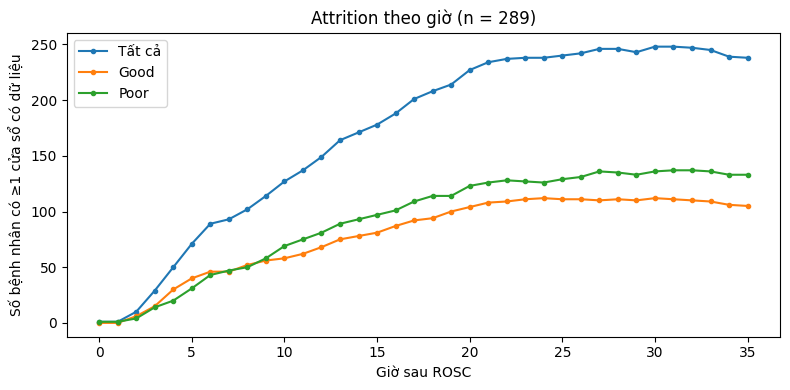

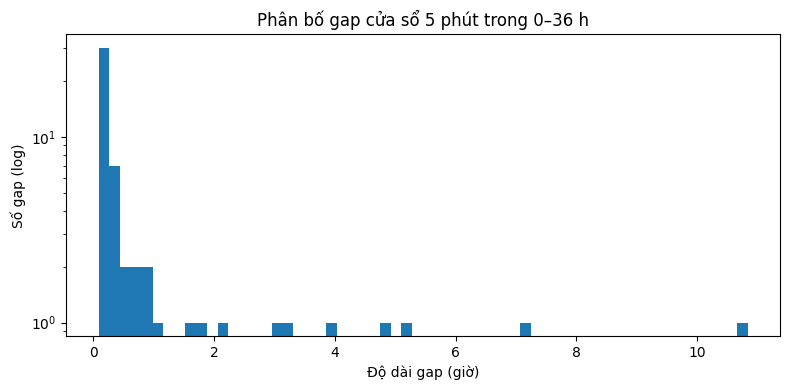

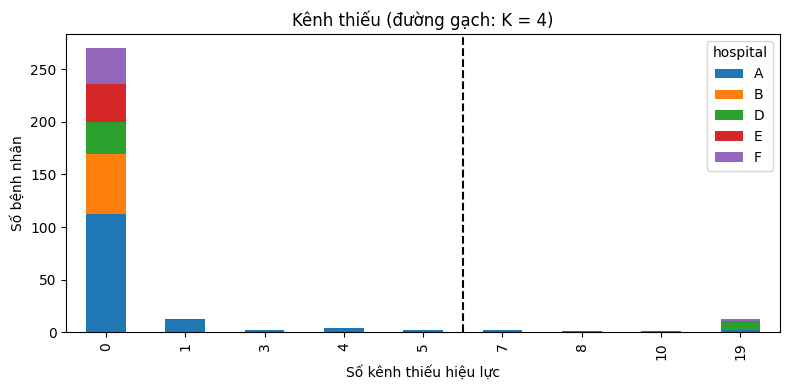

In [ ]:
# ==== CELL 11 — Bảng cohort theo bệnh viện, Wilson nếu 0 FP, attrition theo giờ, gaps, hình ====
def _ct(df, col, prefix):
    t = pd.crosstab(df.hospital, df[col], margins=True, margins_name="ALL").drop(columns="ALL")
    t.columns = [f"{prefix}{c}" for c in t.columns]
    return t

def cohort_table(df):
    df = df.copy(); df["cpc_i"] = df.cpc.astype(int)
    n = pd.crosstab(df.hospital, df.outcome, margins=True, margins_name="ALL")
    t = pd.DataFrame({"n": n["ALL"], "n_good": n.get("Good", 0), "n_poor": n.get("Poor", 0)})
    t["pct_poor"] = (t.n_poor / t.n).round(3)
    t = t.join(_ct(df, "cpc_i", "CPC")).join(_ct(df, "ttm_group", "TTM_"))
    by = df.groupby("hospital")
    extra = pd.DataFrame({"age_median": by.age.median(), "pct_ohca": by.ohca.apply(lambda x: (x == True).mean()),
                          "pct_shockable": by.shockable.apply(lambda x: (x == True).mean())})
    extra.loc["ALL"] = [df.age.median(), (df.ohca == True).mean(), (df.shockable == True).mean()]
    return t.join(extra.round(3))

cohort_all = cohort_table(pat[pat.label_ok])
cohort_inc = cohort_table(inc)
print("Cohort INCLUDED theo bệnh viện:"); display(cohort_inc)

good_ids = set(inc.patient_id[inc.outcome == "Good"]); poor_ids = set(inc.patient_id[inc.outcome == "Poor"])
def _wrow(scope, name, ids):
    ids = set(ids); ng, npo = len(ids & good_ids), len(ids & poor_ids)
    return {"scope": scope, "set": name, "n_good": ng, "n_poor": npo,
            "wilson_lower95_if_0FP": round(wilson_ci(ng, ng)[0], 4) if ng else np.nan,
            "rule_of_three_upper_FPR": round(3 / ng, 4) if ng else np.nan}
rows = [_wrow("pooled_out_of_fold", "ALL", inc.patient_id)]
for f in folds:
    rows.append(_wrow("outer_test", f"fold{f['fold']}", f["test"]))
    rows.append(_wrow("inner_val", f"fold{f['fold']}", f["val"]))
for h in sorted(inc.hospital.dropna().unique()):
    rows.append(_wrow("LOHO_test", f"hospital_{h}", inc.patient_id[inc.hospital == h]))
wilson_df = pd.DataFrame(rows)
need_df = pd.DataFrame({"target_wilson_lower95": [0.95, 0.97, 0.99],
                        "n_good_needed_if_0FP": [n_good_needed(t) for t in (0.95, 0.97, 0.99)]})
display(wilson_df); display(need_df)

hc = hourly_df.loc[hourly_df.index.intersection(inc.patient_id)]
lab = inc.set_index("patient_id").outcome.reindex(hc.index)
att = pd.DataFrame({"hour": range(H), "n_all": hc.sum(0).values,
                    "n_good": hc[lab == "Good"].sum(0).values, "n_poor": hc[lab == "Poor"].sum(0).values,
                    "n_any_data_up_to_h": (hc.cummax(axis=1).sum(0)).values})
display(att.T)

gi = gaps_df[gaps_df.patient_id.isin(inc.patient_id)]
gap_q = gi.gap_len_h.quantile([.5, .75, .9, .95, .99]).round(3).rename("gap_len_h") if len(gi) else pd.Series(dtype=float)
gmax_tab = pd.DataFrame([{"G_max_h": g, "n_patients_with_gap_gt": int(gi[gi.gap_len_h > g].patient_id.nunique()),
                          "n_gaps_gt": int((gi.gap_len_h > g).sum())} for g in (1, 2, 3, 4, 6)])
print("Gap cửa sổ (included): tổng", len(gi), "gap ở", gi.patient_id.nunique(), "bệnh nhân")
display(gap_q); display(gmax_tab)

# Hình
fig, ax = plt.subplots(figsize=(8, 4))
for col, lb in [("n_all", "Tất cả"), ("n_good", "Good"), ("n_poor", "Poor")]:
    ax.plot(att.hour, att[col], marker="o", ms=3, label=lb)
ax.set(xlabel="Giờ sau ROSC", ylabel="Số bệnh nhân có ≥1 cửa sổ có dữ liệu", title=f"Attrition theo giờ (n = {len(inc)})")
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / "audit_hourly_coverage.png", dpi=150); plt.show()

if len(gi):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(gi.gap_len_h, bins=60, log=True)
    ax.set(xlabel="Độ dài gap (giờ)", ylabel="Số gap (log)", title="Phân bố gap cửa sổ 5 phút trong 0–36 h")
    fig.tight_layout(); fig.savefig(FIG_DIR / "audit_gap_length_hist.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
pd.crosstab(pre.n_missing_eff, pre.hospital).plot(kind="bar", stacked=True, ax=ax)
ax.axvline(K + 0.5, ls="--", c="k"); ax.set(xlabel="Số kênh thiếu hiệu lực", ylabel="Số bệnh nhân", title=f"Kênh thiếu (đường gạch: K = {K})")
fig.tight_layout(); fig.savefig(FIG_DIR / "audit_missing_channels.png", dpi=150); plt.show()

for name, df in {"cohort_table_included.csv": cohort_inc, "cohort_table_all_labeled.csv": cohort_all,
                 "wilson_table.csv": wilson_df, "hourly_attrition.csv": att, "gap_summary.csv": gmax_tab,
                 "channel_missing_by_hospital.csv": tab_ch_hosp, "K_sensitivity.csv": sens_K,
                 "artifact_criteria_rates.csv": crit_rates, "hospital_signal_scale.csv": scale}.items():
    df.to_csv(AUDIT_DIR / name)

In [ ]:
# ==== CELL 12 — audit_patients.csv + audit_report.md + data_hash + kiểm tra Definition of Done ====
pat.to_csv(AUDIT_DIR / "audit_patients.csv", index=False)
DATA_HASH = sha256_file(AUDIT_DIR / "audit_segments.csv")
(AUDIT_DIR / "data_hash.txt").write_text(
    f"audit_segments.csv  {DATA_HASH}\nfolds.json  {FOLDS_SHA}\nartifact_thresholds.json  {THR_SHA}\nconfig  {CFG_HASH}\n")

L = []
L += ["# Phase 1 — Audit dữ liệu I-CARE v2.1 (0–36 h sau ROSC)", "",
      f"- Tạo lúc: {datetime.datetime.now().isoformat(timespec='seconds')}",
      f"- config sha256: `{CFG_HASH}` · folds sha256: `{FOLDS_SHA}` · artifact_thresholds sha256: `{THR_SHA}` · data sha256: `{DATA_HASH}`",
      "- Đây là số liệu mô tả dữ liệu, KHÔNG phải kết quả mô hình.", ""]
L += ["## 1. Inventory", f"- Thư mục bệnh nhân: {len(PATIENTS)} (kỳ vọng 607)",
      f"- Có nhãn hợp lệ: {int(pat.label_ok.sum())}", f"- QC header: `{QC_HDR}`", ""]
L += ["## 2. Kênh (19 kênh 10–20)", "Tỷ lệ bệnh nhân thiếu kênh (header) theo bệnh viện:", "",
      tab_ch_hosp.to_markdown(), "", f"Độ nhạy cỡ mẫu theo K (đang dùng K = {K}):", "", sens_K.to_markdown(index=False), ""]
L += ["## 3. Phủ thời gian và gaps", "Attrition theo giờ (bệnh nhân included):", "", att.to_markdown(index=False), "",
      "Phân vị độ dài gap cửa sổ (giờ):", "", gap_q.to_frame().to_markdown(), "", gmax_tab.to_markdown(index=False), ""]
L += ["## 4. Tiêu chí loại", "",
      pd.crosstab(pat.hospital.fillna("?"), pat.exclusion_reason.replace("", "INCLUDED"), margins=True).to_markdown(), ""]
L += ["## 5. Cohort included theo bệnh viện", "", cohort_inc.to_markdown(), ""]
L += ["## 6. Chia tập (5-fold phân tầng outcome × bệnh viện, inner-val 20 %)", "", strat_df.to_markdown(index=False), ""]
L += ["## 7. Ngưỡng artifact (phân vị trên train fold 0)", "", f"```json\n{json.dumps(THR, indent=2)}\n```", "",
      crit_rates.to_markdown(), "", "Thang tín hiệu theo bệnh viện:", "", scale.to_markdown(), "",
      "Tỷ lệ đoạn hợp lệ ước lượng trên mẫu:", "", valid_by_h.to_markdown(), ""]
L += ["## 8. Cỡ mẫu cho ràng buộc 0 FP (Wilson 95 %)", "", wilson_df.to_markdown(index=False), "", need_df.to_markdown(index=False), ""]
L += ["## 9. Ghi chú",
      "- Ngưỡng artifact chỉ ước lượng trên mẫu khối 60 s; tiêu chí W_min theo cửa sổ HỢP LỆ (sau artifact) được kiểm lại ở Phase 2.",
      "- Trang mô tả I-CARE v2.1 vừa mô tả thời điểm bắt đầu file tính từ ngừng tim (ví dụ 0284_001_004), vừa ghi nhãn thời gian EEG tính từ ROSC; dự án dùng mốc ROSC theo đặc tả.",
      "- Đơn vị tín hiệu trong header là 'nu' → ngưỡng biên độ là tương đối, xem bảng thang theo bệnh viện.", ""]
(AUDIT_DIR / "audit_report.md").write_text("\n".join(L), encoding="utf-8")

DOD = {
    "audit_patients.csv": (AUDIT_DIR / "audit_patients.csv").exists(),
    "audit_gaps.csv": (AUDIT_DIR / "audit_gaps.csv").exists(),
    "inclusion_list.csv": (AUDIT_DIR / "inclusion_list.csv").exists(),
    "audit_report.md (n_Good/n_Poor theo bệnh viện + Wilson)": (AUDIT_DIR / "audit_report.md").exists(),
    "folds.json + sha256": (SPLIT_DIR / "folds.json.sha256").exists(),
    "artifact_thresholds.json + sha256": (CFG_DIR / "frozen" / "artifact_thresholds.json.sha256").exists(),
    "đủ 607 thư mục bệnh nhân": len(PATIENTS) == 607,
}
for k, v in DOD.items(): print(("oke" if v else "no ok"), k)
print(f"\nIncluded: {len(inc)} | Good: {len(good_ids)} | Poor: {len(poor_ids)} | "
      f"Wilson lower 95 % nếu 0 FP trên {len(good_ids)} Good = {wilson_ci(len(good_ids), len(good_ids))[0]:.4f}")

oke audit_patients.csv
oke audit_gaps.csv
oke inclusion_list.csv
oke audit_report.md (n_Good/n_Poor theo bệnh viện + Wilson)
oke folds.json + sha256
oke artifact_thresholds.json + sha256
oke đủ 607 thư mục bệnh nhân

Included: 289 | Good: 121 | Poor: 168 | Wilson lower 95 % nếu 0 FP trên 121 Good = 0.9692


preprocessing

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!pip -q install wfdb pyyaml pyarrow tabulate
import torch, wfdb, scipy, numpy
print("torch", torch.__version__, "| wfdb", wfdb.__version__, "| scipy", scipy.__version__, "| numpy", numpy.__version__)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.1 MB/s eta 0:00:00
torch 2.11.0+cpu | wfdb 4.3.1 | scipy 1.16.3 | numpy 2.1.3


In [ ]:
import os
for d in ["/content/drive/MyDrive/cnn_transformer/src/icare/preprocess", "/content/drive/MyDrive/cnn_transformer/tests"]:
    os.makedirs(d, exist_ok=True)
for f in ["/content/drive/MyDrive/cnn_transformer/src/icare/__init__.py", "/content/drive/MyDrive/cnn_transformer/src/icare/preprocess/__init__.py"]:
    open(f, "a").close()
print("OK")

OK


In [ ]:
%%writefile /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/artifact_screen.py

from __future__ import annotations

import re
from dataclasses import dataclass

import numpy as np
from scipy import signal as sps

STD19 = ["Fp1", "Fp2", "F7", "F8", "F3", "F4", "T3", "T4", "C3", "C4",
         "T5", "T6", "P3", "P4", "O1", "O2", "Fz", "Cz", "Pz"]
FEATURES = ["ptp_dig", "plateau_frac", "std_raw", "hf_ratio", "max_abs_bp", "std_bp"]
CRITERIA = ["const", "flat", "amp", "hf", "clip"]


def make_canon_channel(standard_19: list[str], aliases: dict[str, str]):
    """Return Phase 1's ``canon_channel`` (Cell 4) bound to the given channel list and alias table."""
    std_up = {c.upper(): c for c in standard_19}
    alias_up = {k.upper(): v.upper() for k, v in aliases.items()}

    def canon_channel(name):
        if name is None:
            return None
        n = re.sub(r"^\s*EEG\s+", "", str(name), flags=re.I).strip()
        n = re.sub(r"[-_ ]?(REF|AVG)$", "", n, flags=re.I).upper()
        return std_up.get(alias_up.get(n, n))
    return canon_channel


@dataclass(frozen=True)
class ArtifactThresholds:
    """Frozen thresholds from Phase 1 (``configs/frozen/artifact_thresholds.json`` → key ``thresholds``)."""
    amp_max_abs_bp: float
    flat_std_raw_min: float
    hf_ratio_max: float | None
    plateau_frac_max: float
    max_bad_ch_frac: float

    @classmethod
    def from_payload(cls, payload: dict) -> "ArtifactThresholds":
        t = payload["thresholds"]
        return cls(float(t["amp_max_abs_bp"]), float(t["flat_std_raw_min"]),
                   None if t.get("hf_ratio_max") is None else float(t["hf_ratio_max"]),
                   float(t["plateau_frac_max"]), float(t["max_bad_ch_frac"]))


_SOS_CACHE: dict = {}


def butter_sos(fs: float, low: float, high: float, order: int) -> np.ndarray:
    """Phase 1 `_sos(fs)`: ``scipy.signal.butter(order, [low, high], 'bandpass', fs=fs, output='sos')`` (cached)."""
    key = (float(fs), float(low), float(high), int(order))
    if key not in _SOS_CACHE:
        _SOS_CACHE[key] = sps.butter(order, [low, high], btype="bandpass", fs=fs, output="sos")
    return _SOS_CACHE[key]


def chunk_features(d_block: np.ndarray, gain: np.ndarray, base: np.ndarray, fs: float,
                   i0: int, a: int, n_ep: int, ss: dict, epoch_sec: int = 10):
    L = int(round(epoch_sec * fs))
    d = np.asarray(d_block, dtype=np.int64)
    phys = (d - base) / gain
    off = i0 - a
    core = slice(off, off + n_ep * L)
    nonconst = d[core].max(0) != d[core].min(0)
    C = d.shape[1]
    xf = xc = None
    if fs > 2 * ss["bp_high"]:
        xf = sps.sosfiltfilt(butter_sos(fs, ss["bp_low"], ss["bp_high"], ss["bp_order"]),
                             phys - phys.mean(0, keepdims=True), axis=0)
        xc = xf - (xf[:, nonconst].mean(1, keepdims=True) if nonconst.any() else 0.0)
    hf_ok = fs > 2 * ss["hf_band"][1]
    out = {k: np.full((n_ep, C), np.nan) for k in FEATURES}
    for e in range(n_ep):
        sl = slice(off + e * L, off + (e + 1) * L)
        dd = d[sl]
        raw = sps.detrend(phys[sl], axis=0)
        mx, mn = dd.max(0), dd.min(0)
        ptp = mx - mn
        plateau = np.where(ptp == 0, 1.0, ((dd == mx).sum(0) + (dd == mn).sum(0)) / dd.shape[0])
        if hf_ok:
            f, P = sps.welch(raw, fs=fs, nperseg=int(round(ss["welch_sec"] * fs)), axis=0)
            hb = (f >= ss["hf_band"][0]) & (f < ss["hf_band"][1])
            lb = (f >= ss["bp_low"]) & (f < ss["bp_high"])
            out["hf_ratio"][e] = P[hb].sum(0) / np.maximum(P[lb].sum(0), 1e-30)
        if xc is not None:
            xe = xc[sl]
            out["max_abs_bp"][e] = np.abs(xe).max(0)
            out["std_bp"][e] = xe.std(0)
        out["ptp_dig"][e] = ptp
        out["plateau_frac"][e] = plateau
        out["std_raw"][e] = raw.std(0)
    return out, xf


def bad_channel_flags(feats: dict, thr: ArtifactThresholds) -> dict:
    """Phase 1 Cell 10 ``bad_channel_flags`` on arrays.  feats[name]: [N, C] → dict criterion -> bool [N, C] + 'bad'."""
    with np.errstate(invalid="ignore"):
        hf = (feats["hf_ratio"] > thr.hf_ratio_max) if thr.hf_ratio_max is not None \
            else np.zeros_like(feats["hf_ratio"], dtype=bool)
        f = {"const": feats["ptp_dig"] == 0,
             "flat": feats["std_raw"] < thr.flat_std_raw_min,
             "amp": feats["max_abs_bp"] > thr.amp_max_abs_bp,
             "hf": hf,
             "clip": feats["plateau_frac"] > thr.plateau_frac_max}
    f["bad"] = np.logical_or.reduce([f[k] for k in CRITERIA])
    return f


def epoch_validity(bad: np.ndarray, eff_cols: np.ndarray, thr: ArtifactThresholds):
    if len(eff_cols) == 0:
        n = bad.shape[0]
        return np.ones(n), np.zeros(n, dtype=bool)
    bad_frac = bad[:, eff_cols].mean(1)
    return bad_frac, bad_frac <= thr.max_bad_ch_frac

Overwriting /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/artifact_screen.py


In [ ]:
%%writefile /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/pipeline.py
from __future__ import annotations

import math
from dataclasses import dataclass, field
from fractions import Fraction
from pathlib import Path
from typing import Callable

import numpy as np
from scipy import signal as sps

from .artifact_screen import (CRITERIA, FEATURES, STD19, ArtifactThresholds, bad_channel_flags,
                              chunk_features, epoch_validity)

N_CH = 19


# ----------------------------------------------------------------------------------------------- I/O abstraction
@dataclass
class RawBlock:
    d: np.ndarray
    gain: np.ndarray
    base: np.ndarray
    sig_name: list
    fs: float


Reader = Callable[[str, str, int, int], RawBlock]


def wfdb_block_reader(data_root: str) -> Reader:
    """Production reader: the exact call Phase 1 Cell 7 used (``wfdb.rdrecord(..., sampfrom, sampto, physical=False)``)."""
    import wfdb  # imported lazily so the numeric code can be tested without wfdb installed

    def read(pid: str, record: str, a: int, b: int) -> RawBlock:
        r = wfdb.rdrecord(str(Path(data_root) / pid / record), sampfrom=int(a), sampto=int(b), physical=False)
        return RawBlock(np.asarray(r.d_signal), np.asarray(r.adc_gain, float), np.asarray(r.baseline, float),
                        list(r.sig_name), float(r.fs))
    return read


# ----------------------------------------------------------------------------------------------- grid helpers
def epoch_range(start_sec: float, end_sec: float, horizon_sec: float, ep_sec: int) -> tuple[int, int]:
    """Epochs [k0, k1) lying fully inside [start, end) ∩ [0, horizon) — same rounding as Phase 1 Cell 6/7."""
    s, e = max(start_sec, 0.0), min(end_sec, horizon_sec)
    return math.ceil(s / ep_sec - 1e-9), math.floor(e / ep_sec + 1e-9)


def merge_intervals(iv, tol):
    """Phase 1 Cell 4 ``merge_intervals`` (copied). Returns (merged, n_true_overlaps)."""
    merged, n_overlap = [], 0
    for s, e in sorted(iv):
        if merged and s <= merged[-1][1] + tol:
            if s < merged[-1][1] - tol:
                n_overlap += 1
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return merged, n_overlap


def phase1_recorded_mask(starts, ends, horizon_sec, ep_sec, n_ep, tol) -> np.ndarray:
    """Phase 1 Cell 6 definition of a 'recorded' epoch (after merging segments ≤ tol s apart). bool [n_ep]."""
    iv = [(max(s, 0.0), min(e, horizon_sec)) for s, e in zip(starts, ends) if min(e, horizon_sec) > max(s, 0.0)]
    merged, _ = merge_intervals(iv, tol)
    rec = np.zeros(n_ep, dtype=bool)
    for s, e in merged:
        k0, k1 = math.ceil(s / ep_sec - 1e-9), math.floor(e / ep_sec + 1e-9)
        if k1 > k0:
            rec[k0:k1] = True
    return rec


def resample_ratio(fs: float, target_fs: int) -> tuple[int, int]:
    """(up, down) with target_fs / fs = up / down. Requires an integer native rate (true for all I-CARE rates)."""
    if abs(fs - round(fs)) > 1e-9:
        raise ValueError(f"non-integer sampling rate {fs}")
    fr = Fraction(int(target_fs), int(round(fs)))
    return fr.numerator, fr.denominator


# ----------------------------------------------------------------------------------------------- normalisation
def normalize_epoch(x: np.ndarray, car_cols: np.ndarray, cfg: dict) -> tuple[np.ndarray, np.ndarray]:
    use = car_cols if car_cols.any() else np.ones_like(car_cols)
    x = x - x[:, use].mean(1, keepdims=True)
    if cfg["detrend"] == "linear":
        x = sps.detrend(x, axis=0)
    eps = cfg["norm_eps"]
    if cfg["norm"] == "zscore":
        center, scale = x.mean(0), x.std(0)
        z = np.where(scale > eps, (x - center) / np.where(scale > eps, scale, 1.0), 0.0)
    elif cfg["norm"] == "robust":
        q25, center, q75 = np.percentile(x, [25, 50, 75], axis=0)
        scale = (q75 - q25) / 1.349
        z = np.where(scale > eps, (x - center) / np.where(scale > eps, scale, 1.0), 0.0)
        z = np.clip(z, -cfg["robust_clip"], cfg["robust_clip"])
    else:
        raise ValueError(f"unknown norm {cfg['norm']!r}")
    with np.errstate(divide="ignore"):
        log_scale = np.where(scale > 0, np.log10(np.where(scale > 0, scale, 1.0)), np.nan)
    return z.T.astype(np.float32), log_scale.astype(np.float32)


# ----------------------------------------------------------------------------------------------- patient context
@dataclass
class PatientSpec:
    patient_id: str
    segments: list
    hp: set
    eff_mask: np.ndarray
    labels: dict = field(default_factory=dict)


@dataclass
class GridConfig:
    """Grid constants from Phase 1 ``grid`` block. horizon_h=36, epoch_sec=10, window_min=5, E_min, W_min, merge_tol_sec."""
    horizon_h: int
    epoch_sec: int
    window_min: int
    E_min: int
    W_min: int
    merge_tol_sec: float

    @property
    def horizon_sec(self) -> int: return self.horizon_h * 3600
    @property
    def n_ep(self) -> int: return self.horizon_sec // self.epoch_sec
    @property
    def e_win(self) -> int: return self.window_min * 60 // self.epoch_sec
    @property
    def w_max(self) -> int: return self.n_ep // self.e_win
    @property
    def ep_per_hour(self) -> int: return 3600 // self.epoch_sec


def _map_channels(sig_name, hp: set, canon) -> list:
    """Column index (in the record) of each STD19 channel that is header_present; first occurrence wins (Phase 1)."""
    idx = {}
    for i, n in enumerate(sig_name):
        c = canon(n)
        if c and c in hp and c not in idx:
            idx[c] = i
    return [(c, idx[c]) for c in STD19 if c in idx]


def process_segment(pid: str, seg: dict, spec: PatientSpec, reader: Reader, canon, thr: ArtifactThresholds,
                    ss: dict, pre: dict, grid: GridConfig, qc_keys: set | None = None) -> dict:
    fs, n_samples, start = float(seg["fs"]), int(seg["n_samples"]), float(seg["start_sec"])
    end = start + n_samples / fs
    k0, k1 = epoch_range(start, end, grid.horizon_sec, grid.epoch_sec)
    T = grid.epoch_sec * pre["target_fs"]
    empty = dict(k=np.zeros(0, np.int64), x=np.zeros((0, N_CH, T), np.float16), valid=np.zeros(0, bool),
                 bad_ch=np.zeros((0, N_CH), bool), bad_frac=np.zeros(0, np.float32),
                 log_scale=np.zeros((0, N_CH), np.float32), crit=np.zeros(len(CRITERIA), np.int64),
                 qc_rows=[], n_eff_missing=0)
    if k1 <= k0:
        return empty
    if fs <= 2 * ss["bp_high"]:
        raise ValueError(f"{pid}/{seg['record']}: fs={fs} too low for the {ss['bp_high']} Hz band-pass")
    L, pad = int(round(grid.epoch_sec * fs)), int(round(ss["pad_sec"] * fs))
    up, down = resample_ratio(fs, pre["target_fs"])
    if (L * up) % down or L * up // down != T:
        raise ValueError(f"fs={fs}: one epoch does not map to exactly {T} samples")

    # chunk plan: identical boundaries to Phase 1 plan_chunks (start at k0, step chunk_epochs)
    CE = pre["chunk_epochs"]
    chunks = []
    for c0 in range(k0, k1, CE):
        n_ep = min(CE, k1 - c0)
        i0 = int(round((c0 * grid.epoch_sec - start) * fs))
        i0 = max(0, min(i0, n_samples - n_ep * L))
        chunks.append((c0, n_ep, i0, max(0, i0 - pad), min(n_samples, i0 + n_ep * L + pad)))
    # group chunks into read blocks
    max_blk = int(pre["read_block_sec"] * fs) if pre["read_block_sec"] > 0 else None
    blocks, cur = [], []
    for ch in chunks:
        if cur and max_blk is not None and ch[4] - cur[0][3] > max_blk:
            blocks.append(cur); cur = []
        cur.append(ch)
    blocks.append(cur)

    ks, xs, valids, bads, bfracs, lscales, qc_rows = [], [], [], [], [], [], []
    crit = np.zeros(len(CRITERIA), np.int64)
    cols = chans = None
    n_eff_missing = 0
    for blk in blocks:
        A, B = blk[0][3], max(c[4] for c in blk)
        rb = reader(pid, seg["record"], A, B)
        if abs(rb.fs - fs) > 1e-6:
            raise ValueError(f"{pid}/{seg['record']}: header fs {rb.fs} != audit fs {fs}")
        if cols is None:
            mapping = _map_channels(rb.sig_name, spec.hp, canon)
            if not mapping:
                raise ValueError(f"{pid}/{seg['record']}: no header_present standard channel")
            chans = [c for c, _ in mapping]
            cols = np.array([i for _, i in mapping])
            pos19 = np.array([STD19.index(c) for c in chans])
            eff_in = np.array([spec.eff_mask[p] for p in pos19], dtype=bool)
            eff_cols = np.flatnonzero(eff_in)                # columns (within chans) that are eff_present
            eff_pos19 = pos19[eff_cols]
            n_eff_missing = int(spec.eff_mask.sum() - len(eff_cols))
            gain, base = rb.gain[cols], rb.base[cols]
        for (c0, n_ep, i0, a, b) in blk:
            d_block = rb.d[a - A:b - A][:, cols]
            feats, xf = chunk_features(d_block, gain, base, fs, i0, a, n_ep, ss, grid.epoch_sec)
            flags = bad_channel_flags(feats, thr)
            bfrac, valid = epoch_validity(flags["bad"], eff_cols, thr)
            for j, cname in enumerate(CRITERIA):
                crit[j] += int(flags[cname][:, eff_cols].sum())
            # model path: polyphase resampling with exact alignment of epoch starts
            off = i0 - a
            j0 = off % down
            Y = sps.resample_poly(xf[j0:, eff_cols], up, down, axis=0)
            cs = (off - j0) * up // down
            for e in range(n_ep):
                k = c0 + e
                xe = Y[cs + e * T: cs + (e + 1) * T]
                car = ~flags["bad"][e, eff_cols] if pre["model_car"] == "good_channels" \
                    else np.ones(len(eff_cols), bool)
                z, ls = normalize_epoch(xe, car, pre)
                x19 = np.zeros((N_CH, T), np.float16)
                x19[eff_pos19] = z.astype(np.float16)
                ls19 = np.full(N_CH, np.nan, np.float32); ls19[eff_pos19] = ls
                b19 = np.zeros(N_CH, bool); b19[eff_pos19] = flags["bad"][e, eff_cols]
                ks.append(k); xs.append(x19); valids.append(bool(valid[e])); bads.append(b19)
                bfracs.append(float(bfrac[e])); lscales.append(ls19)
                if qc_keys and (seg["record"], k) in qc_keys:
                    for jc, cname in enumerate(chans):
                        row = {"patient_id": pid, "record": seg["record"], "epoch_k": k, "ch": cname}
                        row.update({f: float(feats[f][e, jc]) for f in FEATURES})
                        row["bad"] = bool(flags["bad"][e, jc])
                        qc_rows.append(row)
    return dict(k=np.asarray(ks, np.int64), x=np.stack(xs), valid=np.asarray(valids, bool),
                bad_ch=np.stack(bads), bad_frac=np.asarray(bfracs, np.float32), log_scale=np.stack(lscales),
                crit=crit, qc_rows=qc_rows, n_eff_missing=n_eff_missing)


def preprocess_patient(spec: PatientSpec, reader: Reader, canon, thr: ArtifactThresholds, ss: dict, pre: dict,
                       grid: GridConfig, qc_keys: set | None = None) -> dict:
    parts, seg_idx = [], []
    for si, seg in enumerate(spec.segments):
        out = process_segment(spec.patient_id, seg, spec, reader, canon, thr, ss, pre, grid, qc_keys)
        if len(out["k"]):
            parts.append(out); seg_idx.append(np.full(len(out["k"]), si, np.int16))
    T = grid.epoch_sec * pre["target_fs"]
    if parts:
        k = np.concatenate([p["k"] for p in parts])
        order = np.argsort(k, kind="stable")
        k_sorted = k[order]
        keep = np.ones(len(k_sorted), bool)
        keep[1:] = k_sorted[1:] != k_sorted[:-1]           # overlapping segments: first (earliest-start) wins
        sel = order[keep]
        cat = lambda name: np.concatenate([p[name] for p in parts])[sel]
        epochs = np.concatenate([p["x"] for p in parts])[sel]
        meta = dict(epoch_k=k[sel], valid_epoch=cat("valid"), bad_ch=cat("bad_ch"), bad_frac=cat("bad_frac"),
                    log_scale=cat("log_scale"), seg_index=np.concatenate(seg_idx)[sel])
        n_dup = int((~keep).sum())
        crit = np.sum([p["crit"] for p in parts], axis=0)
        qc_rows = [r for p in parts for r in p["qc_rows"]]
        n_eff_missing = max(p["n_eff_missing"] for p in parts)
    else:
        epochs = np.zeros((0, N_CH, T), np.float16)
        meta = dict(epoch_k=np.zeros(0, np.int64), valid_epoch=np.zeros(0, bool), bad_ch=np.zeros((0, N_CH), bool),
                    bad_frac=np.zeros(0, np.float32), log_scale=np.zeros((0, N_CH), np.float32),
                    seg_index=np.zeros(0, np.int16))
        n_dup, crit, qc_rows, n_eff_missing = 0, np.zeros(len(CRITERIA), np.int64), [], 0
    meta["t_start_sec"] = meta["epoch_k"].astype(np.float64) * grid.epoch_sec

    # ---- summaries on the grid
    stored = np.zeros(grid.n_ep, bool); stored[meta["epoch_k"]] = True
    valid = np.zeros(grid.n_ep, bool); valid[meta["epoch_k"][meta["valid_epoch"]]] = True
    rec_p1 = phase1_recorded_mask([s["start_sec"] for s in spec.segments],
                                  [s["start_sec"] + s["n_samples"] / s["fs"] for s in spec.segments],
                                  grid.horizon_sec, grid.epoch_sec, grid.n_ep, grid.merge_tol_sec)
    per_h = lambda m: m.reshape(grid.horizon_h, grid.ep_per_hour).sum(1).astype(int).tolist()
    win = lambda m: m.reshape(grid.w_max, grid.e_win).sum(1) >= grid.E_min
    n_eff_ep = int(len(meta["epoch_k"]) * spec.eff_mask.sum())
    summary = dict(
        n_epochs_stored=int(stored.sum()), n_epochs_valid=int(valid.sum()),
        n_epochs_phase1_recorded=int(rec_p1.sum()),
        n_epochs_dropped_vs_phase1=int((rec_p1 & ~stored).sum()),     # straddle a segment boundary / gap ≤ tol
        n_epochs_stored_not_phase1=int((stored & ~rec_p1).sum()),     # must be 0
        n_duplicate_epochs=n_dup, n_eff_channel_missing_in_segment=n_eff_missing,
        n_recorded_per_hour=per_h(stored), n_valid_per_hour=per_h(valid),
        n_windows_recorded=int(win(stored).sum()), n_windows_valid=int(win(valid).sum()),
        n_windows_phase1_rule=int(win(rec_p1).sum()),
        meets_W_min_valid=bool(win(valid).sum() >= grid.W_min),
        first_valid_epoch_h=(float(np.flatnonzero(valid)[0] * grid.epoch_sec / 3600) if valid.any() else None),
        criterion_rate_eff={c: (float(crit[j] / n_eff_ep) if n_eff_ep else None) for j, c in enumerate(CRITERIA)},
        n_channels_eff=int(spec.eff_mask.sum()),
    )
    return dict(epochs=epochs, epoch_meta=meta, channel_mask=spec.eff_mask.astype(bool), summary=summary,
                qc_rows=qc_rows)

Overwriting /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/pipeline.py


In [ ]:
%%writefile /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/io_phase1.py
from __future__ import annotations

import hashlib
import json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from .artifact_screen import STD19, ArtifactThresholds, make_canon_channel
from .pipeline import GridConfig, PatientSpec


def sha256_file(path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()


def _read_sidecar(path: Path) -> str:
    return Path(str(path) + ".sha256").read_text().split()[0].strip()


def _read_data_hash(path: Path) -> dict:
    out = {}
    for line in path.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 2:
            out[parts[0]] = parts[-1]
    return out


@dataclass
class Phase1Context:
    root: Path
    cfg1: dict
    grid: GridConfig
    ss: dict
    thr: ArtifactThresholds
    canon: object
    hashes: dict
    included: pd.DataFrame
    specs: dict          # patient_id -> PatientSpec


def verify_frozen(root) -> dict:
    """Check every Phase 1 hash. Returns dict of verified hashes; raises RuntimeError on any mismatch."""
    root = Path(root)
    p = {"config": root / "configs" / "audit_phase1.yaml",
         "thresholds": root / "configs" / "frozen" / "artifact_thresholds.json",
         "folds": root / "data" / "splits" / "folds.json",
         "segments": root / "data" / "audit" / "audit_segments.csv",
         "data_hash": root / "data" / "audit" / "data_hash.txt"}
    missing = [str(v) for v in p.values() if not v.exists()]
    missing += [str(p[k]) + ".sha256" for k in ("thresholds", "folds") if not Path(str(p[k]) + ".sha256").exists()]
    if missing:
        raise RuntimeError("Thiếu file Phase 1 (không chạy Phase 2):\n  " + "\n  ".join(missing))
    got = {k: sha256_file(p[k]) for k in ("config", "thresholds", "folds", "segments")}
    dh = _read_data_hash(p["data_hash"])
    problems = []
    for k in ("thresholds", "folds"):
        if got[k] != _read_sidecar(p[k]):
            problems.append(f"{p[k].name}: sha256 file hiện tại {got[k][:12]} ≠ .sha256 {_read_sidecar(p[k])[:12]}")
    for key, name in [("segments", "audit_segments.csv"), ("folds", "folds.json"),
                      ("thresholds", "artifact_thresholds.json"), ("config", "config")]:
        if dh.get(name) != got[key]:
            problems.append(f"data_hash.txt[{name}] = {str(dh.get(name))[:12]} ≠ hiện tại {got[key][:12]}")
    payload = json.loads(p["thresholds"].read_text(encoding="utf-8"))
    if payload.get("config_sha256") != got["config"]:
        problems.append("artifact_thresholds.json.config_sha256 ≠ sha256(audit_phase1.yaml)")
    if payload.get("folds_sha256") != got["folds"]:
        problems.append("artifact_thresholds.json.folds_sha256 ≠ sha256(folds.json)")
    if problems:
        raise RuntimeError("Phase 1 frozen files KHÔNG khớp hash → dừng (freeze protocol):\n  " + "\n  ".join(problems))
    return got


def load_context(root) -> Phase1Context:
    """Verify hashes, then build one PatientSpec per included patient."""
    root = Path(root)
    hashes = verify_frozen(root)
    cfg1 = yaml.safe_load((root / "configs" / "audit_phase1.yaml").read_text(encoding="utf-8"))
    g = cfg1["grid"]
    grid = GridConfig(int(g["horizon_h"]), int(g["epoch_sec"]), int(g["window_min"]), int(g["E_min"]),
                      int(g["W_min"]), float(g["merge_tol_sec"]))
    if cfg1["channels"]["standard_19"] != STD19:
        raise RuntimeError("Thứ tự 19 kênh trong audit_phase1.yaml khác STD19 của Phase 2")
    canon = make_canon_channel(cfg1["channels"]["standard_19"], cfg1["channels"]["aliases"])
    thr = ArtifactThresholds.from_payload(
        json.loads((root / "configs" / "frozen" / "artifact_thresholds.json").read_text(encoding="utf-8")))

    A = root / "data" / "audit"
    inc = pd.read_csv(A / "inclusion_list.csv", dtype={"patient_id": str, "channel_mask_eff": str})
    inc = inc[inc["included"].astype(str).str.lower() == "true"].copy()
    bad_mask = ~inc.channel_mask_eff.fillna("").str.fullmatch(r"[01]{19}")
    if bad_mask.any():
        raise RuntimeError(f"channel_mask_eff không hợp lệ cho: {inc.patient_id[bad_mask].tolist()[:10]}")
    chan = pd.read_csv(A / "audit_channels.csv", dtype={"patient_id": str})
    chan = chan[chan.header_present.astype(str).str.lower() == "true"]
    hp = chan.groupby("patient_id").ch.apply(set).to_dict()
    seg = pd.read_csv(A / "audit_segments.csv", dtype={"patient_id": str, "record": str})
    err = seg["error"].fillna("").astype(str)
    H_SEC = grid.horizon_sec
    seg_ok = seg[(err == "") & np.isfinite(seg.start_sec) & (seg.fs > 0) & (seg.start_sec < H_SEC)]
    seg_by = {pid: g.sort_values("start_sec") for pid, g in seg_ok.groupby("patient_id")}
    pat = pd.read_csv(A / "audit_patients.csv", dtype={"patient_id": str}).set_index("patient_id")

    specs = {}
    for r in inc.itertuples():
        pid = r.patient_id
        g = seg_by.get(pid)
        segments = [] if g is None else [dict(record=s.record, start_sec=float(s.start_sec), fs=float(s.fs),
                                              n_samples=int(s.n_samples)) for s in g.itertuples()]
        P = pat.loc[pid] if pid in pat.index else None
        lab = dict(hospital=r.hospital, outcome=r.outcome, cpc=None if pd.isna(r.cpc) else int(r.cpc),
                   y=1 if r.outcome == "Poor" else 0,
                   ttm=None if P is None or pd.isna(P.get("ttm")) else float(P.get("ttm")),
                   rosc_min=None if P is None or pd.isna(P.get("rosc_min")) else float(P.get("rosc_min")),
                   phase1_n_windows_present=None if P is None or pd.isna(P.get("n_windows_present"))
                   else int(P.get("n_windows_present")))
        specs[pid] = PatientSpec(pid, segments, hp.get(pid, set()),
                                 np.array([c == "1" for c in r.channel_mask_eff], dtype=bool), lab)
    return Phase1Context(root, cfg1, grid, dict(cfg1["signal_sampling"]), thr, canon, hashes, inc, specs)

Overwriting /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/io_phase1.py


In [ ]:
%%writefile /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/cache_writer.py
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path
from typing import Callable

import numpy as np

FILES = ["epochs.pt", "epoch_meta.pt", "channel_mask.pt", "meta.json"]


def torch_saver() -> Callable[[object, Path], None]:
    """Production saver: numpy arrays → torch tensors → torch.save (zip format, loadable with mmap=True)."""
    import torch

    def conv(o):
        if isinstance(o, np.ndarray):
            return torch.from_numpy(np.ascontiguousarray(o))
        if isinstance(o, dict):
            return {k: conv(v) for k, v in o.items()}
        return o

    def save(obj, path):
        torch.save(conv(obj), str(path))
    return save


def _sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()


def is_done(out_dir, run_hash: str) -> bool:
    p = Path(out_dir) / "_DONE.json"
    if not p.exists():
        return False
    try:
        return json.loads(p.read_text()).get("run_hash") == run_hash
    except Exception:
        return False


def write_patient(out_dir, result: dict, meta_json: dict, run_hash: str, save_pt: Callable) -> dict:
    """Write files as *.tmp then os.replace (atomic per file); _DONE.json last. Returns {file: sha256}."""
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    done = out / "_DONE.json"
    if done.exists():
        done.unlink()                                   # invalidate before rewriting
    objs = {"epochs.pt": result["epochs"], "epoch_meta.pt": result["epoch_meta"],
            "channel_mask.pt": result["channel_mask"]}
    for name, obj in objs.items():
        tmp = out / (name + ".tmp")
        save_pt(obj, tmp)
        os.replace(tmp, out / name)
    tmp = out / "meta.json.tmp"
    tmp.write_text(json.dumps(meta_json, indent=2, ensure_ascii=False, default=_json_default), encoding="utf-8")
    os.replace(tmp, out / "meta.json")
    shas = {f: _sha256(out / f) for f in FILES}
    tmp = out / "_DONE.json.tmp"
    tmp.write_text(json.dumps({"run_hash": run_hash, "sha256": shas}, indent=2))
    os.replace(tmp, done)
    return shas


def _json_default(o):
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.bool_): return bool(o)
    if isinstance(o, np.ndarray): return o.tolist()
    raise TypeError(type(o))

Overwriting /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/cache_writer.py


In [ ]:
%%writefile /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/runner.py
from __future__ import annotations

import datetime
import hashlib
import json
import platform
import time
import traceback
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import numpy as np

from .cache_writer import is_done, torch_saver, write_patient
from .io_phase1 import load_context
from .artifact_screen import STD19
from .pipeline import preprocess_patient, wfdb_block_reader

CODE_FILES = ["artifact_screen.py", "pipeline.py", "io_phase1.py", "cache_writer.py", "runner.py"]


def compute_run_hash(pre: dict, phase1_hashes: dict, code_dir) -> str:
    """sha256 over: Phase 2 config + Phase 1 frozen hashes + source code of this package."""
    h = hashlib.sha256()
    h.update(json.dumps(pre, sort_keys=True).encode())
    h.update(json.dumps(phase1_hashes, sort_keys=True).encode())
    for f in CODE_FILES:
        h.update((Path(code_dir) / f).read_bytes())
    return h.hexdigest()


def _versions() -> dict:
    out = {"python": platform.python_version()}
    for m in ("numpy", "scipy", "wfdb", "torch"):
        try:
            out[m] = __import__(m).__version__
        except Exception:
            out[m] = None
    return out


_G: dict = {}


def init_worker(root, pre, run_hash, qc_keys_by_pid, reader=None, saver=None):
    """Per-process setup. `reader`/`saver` are injectable for tests; default = wfdb / torch."""
    ctx = load_context(root)
    _G.update(ctx=ctx, pre=pre, run_hash=run_hash, qc=qc_keys_by_pid or {},
              reader=reader or wfdb_block_reader(ctx.cfg1["paths"]["data_root"]),
              saver=saver or torch_saver(), out_root=Path(root) / "data" / "processed",
              qc_dir=Path(root) / "data" / "audit" / "phase2_qc")


def run_one(pid: str, overwrite: bool = False) -> dict:
    """Process one patient unless already done with the same run_hash. Never raises; returns a status row."""
    ctx, pre = _G["ctx"], _G["pre"]
    out_dir = _G["out_root"] / pid
    if not overwrite and is_done(out_dir, _G["run_hash"]):
        return {"patient_id": pid, "status": "skipped_done"}
    t0 = time.time()
    try:
        spec = ctx.specs[pid]
        res = preprocess_patient(spec, _G["reader"], ctx.canon, ctx.thr, ctx.ss, pre, ctx.grid,
                                 qc_keys=_G["qc"].get(pid))
        s = res["summary"]
        meta = dict(patient_id=pid, **spec.labels, channel_order=list(STD19),
            channel_mask=[int(v) for v in spec.eff_mask],
            grid=dict(epoch_sec=ctx.grid.epoch_sec, window_min=ctx.grid.window_min, horizon_h=ctx.grid.horizon_h,
                      E_min=ctx.grid.E_min, W_min=ctx.grid.W_min, time_origin="ROSC (Phase 1 convention)"),
            fs_native=sorted({float(sg["fs"]) for sg in spec.segments}),
            preprocess=pre, **s, run_hash=_G["run_hash"], phase1_hashes=ctx.hashes, versions=_versions(),
            created=datetime.datetime.now().isoformat(timespec="seconds"))
        write_patient(out_dir, res, meta, _G["run_hash"], _G["saver"])
        if res["qc_rows"]:
            import pandas as pd
            _G["qc_dir"].mkdir(parents=True, exist_ok=True)
            pd.DataFrame(res["qc_rows"]).to_csv(_G["qc_dir"] / f"{pid}_features.csv", index=False)
        return {"patient_id": pid, "status": "ok", "sec": round(time.time() - t0, 1),
                "n_epochs": s["n_epochs_stored"], "n_valid": s["n_epochs_valid"],
                "n_windows_valid": s["n_windows_valid"], "meets_W_min_valid": s["meets_W_min_valid"],
                "dropped_vs_phase1": s["n_epochs_dropped_vs_phase1"],
                "stored_not_phase1": s["n_epochs_stored_not_phase1"],
                "eff_missing": s["n_eff_channel_missing_in_segment"], "dup": s["n_duplicate_epochs"]}
    except Exception as e:
        return {"patient_id": pid, "status": "error", "error": repr(e),
                "trace": traceback.format_exc()[-1500:], "sec": round(time.time() - t0, 1)}


def run_all(root, pre, run_hash, pids, qc_keys_by_pid=None, n_workers=2, overwrite=False, progress=None):
    """Parallel driver (one patient per task). n_workers=0 → run in this process (debugging)."""
    rows = []
    if n_workers <= 0:
        init_worker(root, pre, run_hash, qc_keys_by_pid)
        for pid in pids:
            rows.append(run_one(pid, overwrite))
            if progress: progress(rows[-1])
        return rows
    with ProcessPoolExecutor(n_workers, initializer=init_worker,
                             initargs=(str(root), pre, run_hash, qc_keys_by_pid)) as ex:
        futs = {ex.submit(run_one, pid, overwrite): pid for pid in pids}
        for f in as_completed(futs):
            rows.append(f.result())
            if progress: progress(rows[-1])
    return rows

Overwriting /content/drive/MyDrive/cnn_transformer/src/icare/preprocess/runner.py


In [ ]:
%%writefile /content/drive/MyDrive/cnn_transformer/tests/test_phase2_preprocess.py

from __future__ import annotations

import copy
import hashlib
import json
import math
import pickle
import sys
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from scipy import signal as sps

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))
from icare.preprocess.artifact_screen import STD19, ArtifactThresholds, make_canon_channel  # noqa: E402
from icare.preprocess.pipeline import (GridConfig, PatientSpec, RawBlock, phase1_recorded_mask,
                                       preprocess_patient)  # noqa: E402
from icare.preprocess import runner  # noqa: E402
from icare.preprocess.io_phase1 import load_context, verify_frozen  # noqa: E402

SS = {"n_chunks": 12, "chunk_sec": 60, "pad_sec": 10, "bp_low": 0.5, "bp_high": 30.0, "bp_order": 4,
      "hf_band": [30.0, 45.0], "welch_sec": 2.0, "n_workers": 8}
GRID = GridConfig(36, 10, 5, 6, 6, 1.0)
PRE = dict(target_fs=100, chunk_epochs=6, pad_sec=10, read_block_sec=600, model_car="good_channels",
           detrend="linear", norm="zscore", norm_eps=1e-6, robust_clip=20.0)
THR = ArtifactThresholds(amp_max_abs_bp=4222.82, flat_std_raw_min=0.542, hf_ratio_max=0.872,
                         plateau_frac_max=0.01, max_bad_ch_frac=0.25)
CANON = make_canon_channel(STD19, {"T7": "T3", "T8": "T4", "P7": "T5", "P8": "T6"})
NAMES = STD19 + ["Fpz"]                       # 20 signals like many I-CARE records


# ------------------------------------------------------------------------------------------------ synthetic data
def make_record(fs, dur_sec, seed, n_sig=20, gain=32.0, freqs_abs=None, start_sec=0.0):
    rng = np.random.default_rng(seed)
    n = int(round(dur_sec * fs))
    if freqs_abs is None:
        x = sps.lfilter([1], [1, -0.95], rng.normal(0, 4, (n, n_sig)), axis=0)   # ~ low-freq dominated noise
    else:                                       # phase locked to ABSOLUTE time since ROSC, for alignment tests
        t = start_sec + np.arange(n) / fs
        x = np.stack([20 * np.sin(2 * np.pi * f * t) for f in freqs_abs], 1)
    d = np.clip(np.round(x * gain), -32768, 32767).astype(np.int16)
    return dict(d=d, gain=np.full(n_sig, gain), base=np.zeros(n_sig), sig_name=list(NAMES[:n_sig]), fs=float(fs))


def make_reader(records):
    def read(pid, record, a, b):
        r = records[(pid, record)]
        return RawBlock(r["d"][a:b].copy(), r["gain"], r["base"], r["sig_name"], r["fs"])
    return read


def spec_for(pid, segs, records, eff_mask=None):
    hp = set(STD19)
    em = np.ones(19, bool) if eff_mask is None else eff_mask
    return PatientSpec(pid, segs, hp, em, {"outcome": "Good", "y": 0})


# ------------------------------------------------------------------------------------------------ Phase 1 reference
def phase1_chunk_stats(read, pid, rec_name, start_sec, fs, n_samples, k, hp_set):
    """VERBATIM copy of Phase 1 Cell 7 `chunk_stats` (only wfdb.rdrecord replaced by the injected reader)."""
    EP_SEC, CHUNK_EP = 10, SS["chunk_sec"] // 10
    _sos = lambda fs: sps.butter(SS["bp_order"], [SS["bp_low"], SS["bp_high"]], btype="bandpass", fs=fs, output="sos")
    L = int(round(EP_SEC * fs)); pad = int(round(SS["pad_sec"] * fs))
    i0 = int(round((k * EP_SEC - start_sec) * fs))
    i0 = max(0, min(i0, n_samples - CHUNK_EP * L))
    a, b = max(0, i0 - pad), min(n_samples, i0 + CHUNK_EP * L + pad)
    r = read(pid, rec_name, a, b)
    d = np.asarray(r.d, dtype=np.int64)
    gain, base = np.asarray(r.gain, float), np.asarray(r.base, float)
    idx = {}
    for i, n in enumerate(r.sig_name):
        c = CANON(n)
        if c and c in hp_set and c not in idx: idx[c] = i
    chans = [c for c in STD19 if c in idx]
    cols = [idx[c] for c in chans]
    d19 = d[:, cols]
    phys = (d19 - base[cols]) / gain[cols]
    off = i0 - a
    core = slice(off, off + CHUNK_EP * L)
    nonconst = d19[core].max(0) != d19[core].min(0)
    xc = None
    if fs > 2 * SS["bp_high"]:
        xf = sps.sosfiltfilt(_sos(fs), phys - phys.mean(0, keepdims=True), axis=0)
        xc = xf - (xf[:, nonconst].mean(1, keepdims=True) if nonconst.any() else 0.0)
    hf_ok = fs > 2 * SS["hf_band"][1]
    rows = []
    for e in range(CHUNK_EP):
        sl = slice(off + e * L, off + (e + 1) * L)
        dd = d19[sl]; raw = sps.detrend(phys[sl], axis=0)
        mx, mn = dd.max(0), dd.min(0); ptp = mx - mn
        plateau = np.where(ptp == 0, 1.0, ((dd == mx).sum(0) + (dd == mn).sum(0)) / dd.shape[0])
        if hf_ok:
            f, P = sps.welch(raw, fs=fs, nperseg=int(round(SS["welch_sec"] * fs)), axis=0)
            hb = (f >= SS["hf_band"][0]) & (f < SS["hf_band"][1])
            lb = (f >= SS["bp_low"]) & (f < SS["bp_high"])
            hf = P[hb].sum(0) / np.maximum(P[lb].sum(0), 1e-30)
        else:
            hf = np.full(len(chans), np.nan)
        if xc is not None:
            xe = xc[sl]; max_abs, std_bp = np.abs(xe).max(0), xe.std(0)
        else:
            max_abs = std_bp = np.full(len(chans), np.nan)
        std_raw = raw.std(0)
        for j, c in enumerate(chans):
            rows.append({"patient_id": pid, "record": rec_name, "epoch_k": k + e, "ch": c,
                         "ptp_dig": int(ptp[j]), "plateau_frac": float(plateau[j]), "std_raw": float(std_raw[j]),
                         "hf_ratio": float(hf[j]), "max_abs_bp": float(max_abs[j]), "std_bp": float(std_bp[j])})
    return rows


# ------------------------------------------------------------------------------------------------ tests
def test_phase1_feature_equivalence():
    """Artifact features of Phase 2 == Phase 1 chunk_stats for every Phase-1-style chunk, at all I-CARE rates."""
    worst = 0.0
    for fs, start in [(256, 3600.0), (500, 7203.0), (250, 0.0), (200, 10.0), (512, 3600.0), (2048, 3600.0)]:
        dur = 300 if fs < 2048 else 130
        rec = make_record(fs, dur, seed=int(fs))
        rec["d"][int(40 * fs):int(41 * fs), 3] = 30000           # amplitude artifact
        rec["d"][:, 7] = 5                                        # constant channel
        records = {("0001", "r1"): rec}
        read = make_reader(records)
        seg = dict(record="r1", start_sec=start, fs=float(fs), n_samples=rec["d"].shape[0])
        qc_keys = {("r1", k) for k in range(0, 100000)}
        res = preprocess_patient(spec_for("0001", [seg], records), read, CANON, THR, SS, PRE, GRID, qc_keys)
        p2 = pd.DataFrame(res["qc_rows"]).set_index(["epoch_k", "ch"])
        k0 = math.ceil(start / 10 - 1e-9); k1 = math.floor((start + seg["n_samples"] / fs) / 10 + 1e-9)
        n_checked = 0
        for k in range(k0, k1 - 6 + 1, 6):                       # Phase 1 plan_chunks candidates
            p1 = pd.DataFrame(phase1_chunk_stats(read, "0001", "r1", start, float(fs), seg["n_samples"], k,
                                                 set(STD19))).set_index(["epoch_k", "ch"])
            for col in ["ptp_dig", "plateau_frac", "std_raw", "hf_ratio", "max_abs_bp", "std_bp"]:
                a, b = p1[col].to_numpy(float), p2.loc[p1.index, col].to_numpy(float)
                assert np.array_equal(np.isnan(a), np.isnan(b))
                m = ~np.isnan(a)
                diff = np.max(np.abs(a[m] - b[m]) / np.maximum(1e-12, np.abs(a[m]))) if m.any() else 0.0
                worst = max(worst, diff)
            n_checked += 1
        assert n_checked >= 2
    assert worst < 1e-12, f"max relative difference vs Phase 1 = {worst}"
    print(f"  max relative difference vs Phase 1 chunk_stats: {worst:.2e}")


def test_grid_alignment_all_rates():
    """Epoch k in the cache holds the signal of [10k, 10k+10) s after ROSC, at every native rate (incl. odd start)."""
    freqs = np.linspace(3.1, 23.3, 20)
    for fs, start in [(256, 3600.0), (250, 0.0), (500, 1234.0), (512, 3601.0), (2048, 3600.0), (200, 3723.0)]:
        dur = 200 if fs < 2048 else 90
        rec = make_record(fs, dur, 0, freqs_abs=freqs, start_sec=start)
        records = {("p", "r"): rec}
        seg = dict(record="r", start_sec=start, fs=float(fs), n_samples=rec["d"].shape[0])
        pre = dict(PRE, model_car="all_present")
        res = preprocess_patient(spec_for("p", [seg], records), make_reader(records), CANON, THR, SS, pre, GRID)
        X, K = res["epochs"].astype(np.float64), res["epoch_meta"]["epoch_k"]
        for i in [1, len(K) // 2, len(K) - 2]:                    # interior epochs (no filter-edge effects)
            t = 10 * K[i] + np.arange(1000) / 100.0
            S = np.stack([np.sin(2 * np.pi * f * t) for f in freqs[:19]])
            ideal = S - S.mean(0)
            ideal = sps.detrend(ideal, axis=1)
            ideal = (ideal - ideal.mean(1, keepdims=True)) / ideal.std(1, keepdims=True)
            r = [np.corrcoef(X[i, c], ideal[c])[0, 1] for c in range(19)]
            assert min(r) > 0.99, (fs, start, K[i], min(r))


def test_gap_not_filled_and_straddle_counted():
    fs = 256
    r1, r2, r3 = make_record(fs, 3605, 1), make_record(fs, 600, 2), make_record(fs, 600, 3)
    records = {("p", "a"): r1, ("p", "b"): r2, ("p", "c"): r3}
    segs = [dict(record="a", start_sec=0.0, fs=fs, n_samples=r1["d"].shape[0]),          # 0 .. 3605 s
            dict(record="b", start_sec=3605.5, fs=fs, n_samples=r2["d"].shape[0]),       # gap 0.5 s ≤ tol
            dict(record="c", start_sec=4205.5 + 7200, fs=fs, n_samples=r3["d"].shape[0])]  # 2 h gap
    res = preprocess_patient(spec_for("p", segs, records), make_reader(records), CANON, THR, SS, PRE, GRID)
    K = res["epoch_meta"]["epoch_k"]; s = res["summary"]
    gap_k = np.arange(math.ceil(4205.5 / 10), math.floor((4205.5 + 7200) / 10))
    assert not np.isin(gap_k, K).any(), "epochs stored inside a recording gap"
    assert 360 not in K, "epoch straddling two segments must not be fabricated"
    assert s["n_epochs_dropped_vs_phase1"] == 1 and s["n_epochs_stored_not_phase1"] == 0
    assert res["epochs"].shape == (len(K), 19, 1000) and res["epochs"].dtype == np.float16
    assert np.all(np.diff(K) > 0)
    assert sum(s["n_recorded_per_hour"]) == s["n_epochs_stored"] and len(s["n_valid_per_hour"]) == 36
    assert np.allclose(res["epoch_meta"]["t_start_sec"], 10.0 * K)


def test_missing_channel_is_zero_and_isolated():
    fs = 256
    rec = make_record(fs, 300, 5)
    records = {("p", "r"): rec}
    seg = dict(record="r", start_sec=0.0, fs=fs, n_samples=rec["d"].shape[0])
    em = np.ones(19, bool); em[STD19.index("T5")] = False
    res1 = preprocess_patient(spec_for("p", [seg], records, em), make_reader(records), CANON, THR, SS, PRE, GRID)
    j = STD19.index("T5")
    assert not res1["channel_mask"][j] and np.all(res1["epochs"][:, j] == 0)
    assert np.all(np.isnan(res1["epoch_meta"]["log_scale"][:, j])) and not res1["epoch_meta"]["bad_ch"][:, j].any()
    rec2 = copy.deepcopy(rec); rec2["d"][:, NAMES.index("T5")] = np.random.default_rng(9).integers(-3000, 3000, rec2["d"].shape[0])
    records2 = {("p", "r"): rec2}
    pre = dict(PRE, model_car="all_present")
    a = preprocess_patient(spec_for("p", [seg], records, em), make_reader(records), CANON, THR, SS, pre, GRID)
    b = preprocess_patient(spec_for("p", [seg], records2, em), make_reader(records2), CANON, THR, SS, pre, GRID)
    assert np.array_equal(a["epochs"], b["epochs"]), "a masked-out channel changed the model tensor"


def test_artifact_epoch_kept_and_masked():
    fs = 500
    rec = make_record(fs, 300, 7)
    for ch in ["Fp1", "Fp2", "F7", "F8", "F3", "F4"]:              # 6/19 = 0.32 > 0.25 → invalid
        rec["d"][int(125 * fs):int(126 * fs), NAMES.index(ch)] = 32000
    records = {("p", "r"): rec}
    seg = dict(record="r", start_sec=0.0, fs=fs, n_samples=rec["d"].shape[0])
    res = preprocess_patient(spec_for("p", [seg], records), make_reader(records), CANON, THR, SS, PRE, GRID)
    m = res["epoch_meta"]; i = int(np.flatnonzero(m["epoch_k"] == 12)[0])
    assert not m["valid_epoch"][i] and m["bad_ch"][i, :6].all() and m["bad_frac"][i] > 0.25
    assert len(m["epoch_k"]) == 30, "invalid epoch must stay in the cache"
    assert np.isfinite(res["epochs"].astype(np.float32)).all()
    assert np.abs(res["epochs"].astype(np.float32)).max() <= math.sqrt(1000) + 1e-3
    assert m["valid_epoch"].sum() >= 28


def test_robust_norm_finite():
    fs = 256
    rec = make_record(fs, 120, 11)
    rec["d"][int(30 * fs), :] = 32000
    records = {("p", "r"): rec}
    seg = dict(record="r", start_sec=0.0, fs=fs, n_samples=rec["d"].shape[0])
    res = preprocess_patient(spec_for("p", [seg], records), make_reader(records), CANON, THR, SS,
                             dict(PRE, norm="robust"), GRID)
    x = res["epochs"].astype(np.float32)
    assert np.isfinite(x).all() and np.abs(x).max() <= 20.0 + 1e-2


# ------------------------------------------------------------------------------------------------ Phase 1 root
def _write_json_hashed(obj, path):
    txt = json.dumps(obj, indent=2, sort_keys=True, ensure_ascii=False)
    Path(path).write_text(txt, encoding="utf-8")
    dg = hashlib.sha256(txt.encode("utf-8")).hexdigest()
    Path(str(path) + ".sha256").write_text(f"{dg}  {Path(path).name}\n")
    return dg


def _sha(p):
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()


def build_fake_phase1_root(root: Path, records: dict, n_pat=3):
    """Mimics every Phase 1 output file Phase 2 reads (same names, columns, hash conventions)."""
    (root / "configs" / "frozen").mkdir(parents=True); (root / "data" / "splits").mkdir(parents=True)
    A = root / "data" / "audit"; A.mkdir(parents=True)
    cfg = {"phase": "01_audit", "seed": 42, "paths": {"data_root": str(root / "raw"), "local_root": str(root)},
           "grid": {"horizon_h": 36, "epoch_sec": 10, "window_min": 5, "E_min": 6, "W_min": 6, "merge_tol_sec": 1.0},
           "channels": {"standard_19": STD19, "known_extra": ["Fpz", "Oz", "F9"],
                        "aliases": {"T7": "T3", "T8": "T4", "P7": "T5", "P8": "T6"}},
           "inclusion": {"K_max_missing": 4, "const_frac_missing": 0.5}, "signal_sampling": SS,
           "artifact": {"q_amp": 99.5, "q_flat": 1.0, "q_hf": 99.0, "plateau_frac_max": 0.01, "max_bad_ch_frac": 0.25},
           "splits": {"n_folds": 5, "inner_val_frac": 0.2, "overwrite": False}, "io": {"n_workers_header": 16}}
    txt = yaml.safe_dump(cfg, sort_keys=False, allow_unicode=True)
    (root / "configs" / "audit_phase1.yaml").write_text(txt, encoding="utf-8")
    cfg_hash = hashlib.sha256(txt.encode()).hexdigest()
    pids = [f"0{284 + i}" for i in range(n_pat)]
    folds_sha = _write_json_hashed({"meta": {"n_patients": len(pids)},
                                    "folds": [{"fold": 0, "train": [], "val": [], "test": pids}]},
                                   root / "data" / "splits" / "folds.json")
    thr_sha = _write_json_hashed({"thresholds": {"amp_max_abs_bp": THR.amp_max_abs_bp,
                                                 "flat_std_raw_min": THR.flat_std_raw_min,
                                                 "hf_ratio_max": THR.hf_ratio_max, "plateau_frac_max": 0.01,
                                                 "max_bad_ch_frac": 0.25},
                                  "folds_sha256": folds_sha, "config_sha256": cfg_hash},
                                 root / "configs" / "frozen" / "artifact_thresholds.json")
    inc, chans, segs, pats = [], [], [], []
    for i, pid in enumerate(pids):
        mask = "0" + "1" * 18 if i == 0 else "1" * 19                  # leading zero must survive CSV round-trip
        inc.append(dict(patient_id=pid, hospital="A", outcome="Poor" if i % 2 else "Good", cpc=4 if i % 2 else 1,
                        included=True, exclusion_reason="", channel_mask_eff=mask))
        for c in STD19:
            chans.append(dict(patient_id=pid, ch=c, dur_frac_present=1.0, header_present=True, partial=False,
                              const_frac=0.0, eff_present=mask[STD19.index(c)] == "1"))
        fs = [256, 500, 2048][i % 3]
        rec = make_record(fs, 400 if fs < 2048 else 200, 100 + i)
        rec_name = f"{pid}_001_001_EEG"
        records[(pid, rec_name)] = rec
        n = rec["d"].shape[0]
        segs.append(dict(patient_id=pid, record=rec_name, seg=1, hour_file=1, fs=float(fs), n_samples=n, n_sig=20,
                         sig_names="|".join(NAMES), units="", fmt="", start_sec=3600.0, end_sec_hdr=3600 + n / fs,
                         utility_freq=50.0, error="", end_sec=3600 + n / fs))
        pats.append(dict(patient_id=pid, hospital="A", outcome=inc[-1]["outcome"], cpc=inc[-1]["cpc"], ttm=33.0,
                         rosc_min=20.0, n_windows_present=int((phase1_recorded_mask([3600.0], [3600 + n / fs], GRID.horizon_sec, 10,
                         GRID.n_ep, 1.0).reshape(GRID.w_max, GRID.e_win).sum(1) >= GRID.E_min).sum())))
    inc.append(dict(patient_id="0999", hospital="B", outcome="Good", cpc=1, included=False,
                    exclusion_reason="no_eeg_0_36h", channel_mask_eff=None))
    pd.DataFrame(inc).to_csv(A / "inclusion_list.csv", index=False)
    pd.DataFrame(chans).to_csv(A / "audit_channels.csv", index=False)
    pd.DataFrame(segs).to_csv(A / "audit_segments.csv", index=False)
    pd.DataFrame(pats).to_csv(A / "audit_patients.csv", index=False)
    (A / "data_hash.txt").write_text(f"audit_segments.csv  {_sha(A / 'audit_segments.csv')}\nfolds.json  {folds_sha}\n"
                                     f"artifact_thresholds.json  {thr_sha}\nconfig  {cfg_hash}\n")
    return pids


def pickle_saver(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def test_context_ids_masks_and_hash_refusal():
    with tempfile.TemporaryDirectory() as td:
        root = Path(td); records = {}
        pids = build_fake_phase1_root(root, records)
        ctx = load_context(root)
        assert sorted(ctx.specs) == pids and "0284" in ctx.specs, "patient_id lost its leading zero"
        assert not ctx.specs["0284"].eff_mask[0] and ctx.specs["0284"].eff_mask[1:].all()
        p = root / "configs" / "frozen" / "artifact_thresholds.json"
        p.write_text(p.read_text().replace("4222.82", "5000.0"))
        try:
            verify_frozen(root)
        except RuntimeError as e:
            assert "KHÔNG khớp" in str(e)
        else:
            raise AssertionError("tampered thresholds were accepted")


def test_runner_end_to_end_and_resume():
    with tempfile.TemporaryDirectory() as td:
        root = Path(td); records = {}
        pids = build_fake_phase1_root(root, records)
        ctx = load_context(root)
        code_dir = Path(runner.__file__).parent
        rh = runner.compute_run_hash(PRE, ctx.hashes, code_dir)
        runner.init_worker(root, PRE, rh, {pids[0]: {(f"{pids[0]}_001_001_EEG", 365)}},
                           reader=make_reader(records), saver=pickle_saver)
        rows = [runner.run_one(p) for p in pids]
        assert all(r["status"] == "ok" for r in rows), rows
        for p in pids:
            d = root / "data" / "processed" / p
            assert all((d / f).exists() for f in ["epochs.pt", "epoch_meta.pt", "channel_mask.pt", "meta.json",
                                                  "_DONE.json"])
            meta = json.loads((d / "meta.json").read_text())
            assert len(meta["n_valid_per_hour"]) == 36 and meta["run_hash"] == rh
            X = pickle.load(open(d / "epochs.pt", "rb"))
            assert X.dtype == np.float16 and X.shape[1:] == (19, 1000)
        q = pd.read_csv(root / "data" / "audit" / "phase2_qc" / f"{pids[0]}_features.csv", dtype={"patient_id": str})
        assert set(q.epoch_k) == {365} and len(q) == 19
        assert runner.run_one(pids[0])["status"] == "skipped_done"
        runner._G["run_hash"] = "different"
        assert runner.run_one(pids[0])["status"] == "ok", "changed config must re-process"


if __name__ == "__main__":
    tests = [v for k, v in sorted(globals().items()) if k.startswith("test_") and callable(v)]
    failed = 0
    for t in tests:
        try:
            t(); print(f"PASS {t.__name__}")
        except Exception as e:
            failed += 1; print(f"FAIL {t.__name__}: {e!r}")
            import traceback; traceback.print_exc()
    print(f"\n{len(tests) - failed}/{len(tests)} passed")
    sys.exit(1 if failed else 0)

Overwriting /content/drive/MyDrive/cnn_transformer/tests/test_phase2_preprocess.py


In [ ]:
import os, sys, json, math, time, hashlib, random, platform, subprocess, datetime, importlib, shutil
from pathlib import Path
import numpy as np, pandas as pd, yaml
from tqdm.auto import tqdm
from IPython.display import display

LOCAL_ROOT = "/content/drive/MyDrive/cnn_transformer/"
ROOT = Path(LOCAL_ROOT); SRC = ROOT / "src"
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
os.environ["PYTHONPATH"] = str(SRC) + os.pathsep + os.environ.get("PYTHONPATH", "")
import icare.preprocess.artifact_screen as _a, icare.preprocess.pipeline as _p, icare.preprocess.io_phase1 as _i
import icare.preprocess.cache_writer as _c, icare.preprocess.runner as _r
for m in (_a, _p, _i, _c, _r): importlib.reload(m)       # sửa code: chạy lại cell %%writefile tương ứng rồi chạy lại cell này
from icare.preprocess import runner
from icare.preprocess.io_phase1 import load_context, sha256_file
from icare.preprocess.pipeline import epoch_range, wfdb_block_reader, _map_channels
from icare.preprocess.artifact_screen import STD19, FEATURES

# Mọi giá trị dưới đây là LỰA CHỌN THIẾT KẾ ĐỀ XUẤT, không phải kết quả đo.
PRE = {
    "target_fs": 100,               # Hz → 1000 mẫu / đoạn 10 s = đầu vào CNN [19, 1000]
    "chunk_epochs": 6,              # PHẢI = chunk_sec/epoch_sec của Phase 1 (60/10) để đặc trưng artifact trùng Phase 1
    "pad_sec": 10,                  # PHẢI = signal_sampling.pad_sec của Phase 1
    "read_block_sec": 600,          # mỗi lần wfdb.rdrecord đọc ≤ 10 phút (RAM); 0 = đọc cả segment
    "model_car": "good_channels",   # CAR cho tensor mô hình: bỏ kênh bị cờ xấu trong đoạn | "all_present"
    "detrend": "linear",            # detrend tuyến tính mỗi (đoạn, kênh) sau CAR | "none"
    "norm": "zscore",               # z-score mỗi (đoạn, kênh) [workflow] | "robust" (median/IQR, clip)
    "norm_eps": 1e-6,               # độ lệch chuẩn ≤ eps → kênh đó = 0 trong đoạn đó
    "robust_clip": 20.0,            # chỉ dùng khi norm="robust"
}
N_WORKERS = 2                       # số tiến trình song song (RAM Colab ~12 GB; I/O Drive thường là nút cổ chai)

ctx = load_context(ROOT)            # ← raise RuntimeError nếu bất kỳ hash Phase 1 nào lệch
assert PRE["pad_sec"] == ctx.ss["pad_sec"] and PRE["chunk_epochs"] * ctx.grid.epoch_sec == ctx.ss["chunk_sec"]
folds = json.loads((ROOT / "data/splits/folds.json").read_text())
fold_ids = set().union(*[set(f["test"]) for f in folds["folds"]])
print("Bệnh nhân included:", len(ctx.specs), "| bệnh nhân trong folds.json:", len(fold_ids))
assert set(ctx.specs) == fold_ids, "inclusion_list và folds.json không cùng tập patient_id"
print("Hash Phase 1 đã kiểm:", {k: v[:12] for k, v in ctx.hashes.items()})
print("Ngưỡng artifact (frozen):", ctx.thr)

cfg2 = {"phase": "02_preprocess", "preprocess": PRE, "n_workers": N_WORKERS, "phase1_hashes": ctx.hashes}
cfg2_txt = yaml.safe_dump(cfg2, sort_keys=False, allow_unicode=True)
(ROOT / "configs" / "preprocess_phase2.yaml").write_text(cfg2_txt, encoding="utf-8")
RUN_HASH = runner.compute_run_hash(PRE, ctx.hashes, SRC / "icare" / "preprocess")
print("run_hash:", RUN_HASH[:16])
random.seed(42); np.random.seed(42)
PROC = ROOT / "data" / "processed"; QC_DIR = ROOT / "data" / "audit" / "phase2_qc"
SIG_DIR = ROOT / "data" / "audit" / "_cache" / "signal_stats"
FIG2 = ROOT / "results" / "figures" / "phase2_qc"; FIG2.mkdir(parents=True, exist_ok=True)

Bệnh nhân included: 289 | bệnh nhân trong folds.json: 289
Hash Phase 1 đã kiểm: {'config': '8ce4c82c3c1a', 'thresholds': 'c4b9542b7f11', 'folds': 'a679ffc73ec7', 'segments': '40f459081dc7'}
Ngưỡng artifact (frozen): ArtifactThresholds(amp_max_abs_bp=4222.819970632214, flat_std_raw_min=0.54196905599702, hf_ratio_max=0.8720905535940108, plateau_frac_max=0.01, max_bad_ch_frac=0.25)
run_hash: 147f908918683d96


In [ ]:
r = subprocess.run([sys.executable, str(ROOT / "tests" / "test_phase2_preprocess.py")], capture_output=True, text=True)
print(r.stdout[-3000:]); print(r.stderr[-3000:])
assert r.returncode == 0, "Có test FAIL — không chạy tiếp."

PASS test_artifact_epoch_kept_and_masked
PASS test_context_ids_masks_and_hash_refusal
PASS test_gap_not_filled_and_straddle_counted
PASS test_grid_alignment_all_rates
PASS test_missing_channel_is_zero_and_isolated
  max relative difference vs Phase 1 chunk_stats: 0.00e+00
PASS test_phase1_feature_equivalence
PASS test_robust_norm_finite
PASS test_runner_end_to_end_and_resume

8/8 passed




In [ ]:
n_ep = {pid: sum(max(0, np.subtract(*epoch_range(s["start_sec"], s["start_sec"] + s["n_samples"] / s["fs"],
                                               ctx.grid.horizon_sec, ctx.grid.epoch_sec)[::-1]))
                 for s in sp.segments) for pid, sp in ctx.specs.items()}
tot_ep = sum(n_ep.values()); bytes_ep = 19 * 1000 * 2
print(f"Tổng đoạn 10 s sẽ lưu (≤, trước khi trừ đoạn trùng): {tot_ep:,}")
print(f"epochs.pt ước tính: {tot_ep * bytes_ep / 1e9:.1f} GB  (+ epoch_meta ≈ {tot_ep * 120 / 1e9:.2f} GB)")
print("Trung vị / bệnh nhân:", f"{np.median(list(n_ep.values())) * bytes_ep / 1e6:.0f} MB")
try:
    du = shutil.disk_usage(LOCAL_ROOT); print(f"shutil.disk_usage(Drive) báo trống: {du.free / 1e9:.1f} GB (con số FUSE, có thể khác quota thật)")
except Exception as e:
    print("Không đọc được dung lượng Drive:", e)

QC_KEYS = {}
for pid in ctx.specs:
    f = SIG_DIR / f"{pid}.parquet"
    if f.exists():
        q = pd.read_parquet(f, columns=["record", "epoch_k"]).drop_duplicates()
        QC_KEYS[pid] = set(zip(q.record.astype(str), q.epoch_k.astype(int)))
print("Bệnh nhân có mẫu Phase 1 để đối chiếu:", len(QC_KEYS), "/", len(ctx.specs))

Tổng đoạn 10 s sẽ lưu (≤, trước khi trừ đoạn trùng): 2,149,248
epochs.pt ước tính: 81.7 GB  (+ epoch_meta ≈ 0.26 GB)
Trung vị / bệnh nhân: 286 MB
shutil.disk_usage(Drive) báo trống: 88.8 GB (con số FUSE, có thể khác quota thật)
Bệnh nhân có mẫu Phase 1 để đối chiếu: 289 / 289


In [ ]:
def compare_with_phase1(pids):
    rows = []
    for pid in pids:
        f1, f2 = SIG_DIR / f"{pid}.parquet", QC_DIR / f"{pid}_features.csv"
        if not (f1.exists() and f2.exists()): continue
        p1 = pd.read_parquet(f1); p2 = pd.read_csv(f2, dtype={"patient_id": str, "record": str})
        p1["record"] = p1.record.astype(str)
        m = p1.merge(p2, on=["record", "epoch_k", "ch"], suffixes=("_p1", "_p2"))
        r = {"patient_id": pid, "n_rows_phase1": len(p1), "n_matched": len(m)}
        for f in FEATURES:
            a, b = m[f + "_p1"].to_numpy(float), m[f + "_p2"].to_numpy(float)
            ok = ~(np.isnan(a) & np.isnan(b))
            r[f"maxrel_{f}"] = float(np.nanmax(np.abs(a[ok] - b[ok]) / np.maximum(np.abs(a[ok]), 1e-12))) if ok.any() else 0.0
        rows.append(r)
    return pd.DataFrame(rows)

In [ ]:
import torch
SMOKE = min((p for p in n_ep if p in QC_KEYS), key=n_ep.get, default=min(n_ep, key=n_ep.get))   # ưu tiên bệnh nhân có mẫu Phase 1
runner.init_worker(ROOT, PRE, RUN_HASH, QC_KEYS)            # reader = wfdb, saver = torch
row = runner.run_one(SMOKE, overwrite=True); print(row)
assert row["status"] == "ok", row.get("trace")
d = PROC / SMOKE
X = torch.load(d / "epochs.pt"); M = torch.load(d / "epoch_meta.pt"); CM = torch.load(d / "channel_mask.pt")
meta = json.loads((d / "meta.json").read_text())
print("epochs", tuple(X.shape), X.dtype, "| channel_mask", CM.int().tolist())
assert X.dtype == torch.float16 and tuple(X.shape[1:]) == (19, 1000) and X.shape[0] == M["epoch_k"].numel()
assert torch.isfinite(X.float()).all() and (X[:, ~CM] == 0).all()
assert len(meta["n_valid_per_hour"]) == 36
try:
    Xm = torch.load(d / "epochs.pt", mmap=True); print("torch.load(mmap=True) dùng được → Phase 3 đọc từng phần được")
except Exception as e:
    print("mmap không dùng được với bản torch này:", repr(e))
print("Giờ có dữ liệu (đầu–cuối):", float(M["t_start_sec"].min()) / 3600, "→", float(M["t_start_sec"].max()) / 3600)
print("Tỷ lệ đoạn hợp lệ:", float(M["valid_epoch"].float().mean()))
c1 = compare_with_phase1([SMOKE]); display(c1 if len(c1) else "(bệnh nhân này không có mẫu Phase 1 để đối chiếu)")
sec_per_ep = row["sec"] / max(1, row["n_epochs"])
print(f"Đo được: {row['sec']} s cho {row['n_epochs']} đoạn → ước tính toàn bộ ≈ "
      f"{sec_per_ep * tot_ep / 3600 / max(1, N_WORKERS):.1f} h với {N_WORKERS} tiến trình (ngoại suy thô, I/O Drive dao động)")

{'patient_id': '0356', 'status': 'ok', 'sec': 9.0, 'n_epochs': 246, 'n_valid': 245, 'n_windows_valid': 9, 'meets_W_min_valid': True, 'dropped_vs_phase1': 0, 'stored_not_phase1': 0, 'eff_missing': 0, 'dup': 0}
epochs (246, 19, 1000) torch.float16 | channel_mask [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
torch.load(mmap=True) dùng được → Phase 3 đọc từng phần được
Giờ có dữ liệu (đầu–cuối): 3.2916666666666665 → 3.9722222222222223
Tỷ lệ đoạn hợp lệ: 0.9959349632263184


,patient_id,n_rows_phase1,n_matched,maxrel_ptp_dig,maxrel_plateau_frac,maxrel_std_raw,maxrel_hf_ratio,maxrel_max_abs_bp,maxrel_std_bp
0,0356,1368,1368,0.0,0.0,2.401040e-16,3.630937e-13,2.378797e-16,2.441644e-16


Đo được: 9.0 s cho 246 đoạn → ước tính toàn bộ ≈ 10.9 h với 2 tiến trình (ngoại suy thô, I/O Drive dao động)


In [ ]:
PIDS = sorted(ctx.specs)
pbar = tqdm(total=len(PIDS), desc="Phase 2")
LOG = ROOT / "data" / "audit" / "phase2_run_log.csv"
def _progress(r):
    pbar.update(1)
    pd.DataFrame([{**r, "logged": datetime.datetime.now().isoformat(timespec="seconds")}]).drop(
        columns=["trace"], errors="ignore").to_csv(LOG, mode="a", header=not LOG.exists(), index=False)
rows = runner.run_all(ROOT, PRE, RUN_HASH, PIDS, QC_KEYS, n_workers=N_WORKERS, progress=_progress)
pbar.close()
run_df = pd.DataFrame(rows)
display(run_df.status.value_counts())
err = run_df[run_df.status == "error"]
if len(err):
    display(err[["patient_id", "error"]]); print(err.iloc[0].trace)

Phase 2:   0%|          | 0/289 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
recs = []
for pid in sorted(ctx.specs):
    d = PROC / pid
    done = (d / "_DONE.json").exists() and json.loads((d / "_DONE.json").read_text()).get("run_hash") == RUN_HASH
    if not done:
        recs.append({"patient_id": pid, "done": False}); continue
    m = json.loads((d / "meta.json").read_text())
    recs.append({"patient_id": pid, "done": True, "hospital": m["hospital"], "outcome": m["outcome"], "cpc": m["cpc"],
                 **{k: m[k] for k in ["n_epochs_stored", "n_epochs_valid", "n_epochs_phase1_recorded",
                                       "n_epochs_dropped_vs_phase1", "n_epochs_stored_not_phase1", "n_duplicate_epochs",
                                       "n_eff_channel_missing_in_segment", "n_windows_recorded", "n_windows_valid",
                                       "n_windows_phase1_rule", "meets_W_min_valid", "first_valid_epoch_h",
                                       "phase1_n_windows_present", "n_channels_eff"]},
                 **{f"rate_{k}": v for k, v in m["criterion_rate_eff"].items()}})
summ = pd.DataFrame(recs)
summ.to_csv(ROOT / "data" / "audit" / "phase2_patient_summary.csv", index=False)
D = summ[summ.done].copy()
CHK = {
    "mọi bệnh nhân included đã xong": bool(summ.done.all()),
    "không lưu đoạn ngoài vùng ghi của Phase 1": int(D.n_epochs_stored_not_phase1.sum()) == 0,
    "không thiếu kênh hiệu lực trong segment": int(D.n_eff_channel_missing_in_segment.sum()) == 0,
    "số cửa sổ (quy tắc Phase 1) = audit Phase 1": bool((D.n_windows_phase1_rule == D.phase1_n_windows_present).all()),
}
for k, v in CHK.items(): print("oke" if v else "NO ", k)
print(f"Đoạn bỏ vì vắt qua ranh giới segment: {int(D.n_epochs_dropped_vs_phase1.sum()):,} / "
      f"{int(D.n_epochs_phase1_recorded.sum()):,} ({D.n_epochs_dropped_vs_phase1.sum() / max(1, D.n_epochs_phase1_recorded.sum()):.4%})")
print(f"Đoạn trùng (segment chồng nhau): {int(D.n_duplicate_epochs.sum())}")
print(f"Tỷ lệ đoạn hợp lệ toàn cohort: {D.n_epochs_valid.sum() / max(1, D.n_epochs_stored.sum()):.4f}")
lt = D[~D.meets_W_min_valid.astype(bool)]
print(f"Bệnh nhân < W_min={ctx.grid.W_min} cửa sổ HỢP LỆ sau artifact: {len(lt)} "
      f"(Good {int((lt.outcome == 'Good').sum())}, Poor {int((lt.outcome == 'Poor').sum())}) — giữ trong cohort; "
      "theo thiết kế họ sẽ ra Vùng Xám-thiếu-dữ-liệu. Quyết định loại hay không là của nhóm, không tự động.")
display(lt[["patient_id", "hospital", "outcome", "n_windows_recorded", "n_windows_valid"]])
print("Tỷ lệ (đoạn × kênh hiệu lực) vi phạm từng tiêu chí, theo bệnh viện:")
display(D.groupby("hospital")[[c for c in D.columns if c.startswith("rate_")]].median().round(4))
cmp_all = compare_with_phase1(sorted(D.patient_id))
cmp_all.to_csv(ROOT / "data" / "audit" / "phase2_vs_phase1_features.csv", index=False)
mx = cmp_all.filter(like="maxrel_").max()
print("Sai khác tương đối lớn nhất so với Phase 1 (mọi bệnh nhân):"); display(mx.to_frame("max_rel_diff"))
print("Dòng Phase 1 được ghép:", int(cmp_all.n_matched.sum()), "/", int(cmp_all.n_rows_phase1.sum()))
CHK["đặc trưng artifact trùng Phase 1 (max rel diff < 1e-9)"] = bool((mx < 1e-9).all())

NO  mọi bệnh nhân included đã xong
oke không lưu đoạn ngoài vùng ghi của Phase 1
oke không thiếu kênh hiệu lực trong segment
oke số cửa sổ (quy tắc Phase 1) = audit Phase 1
Đoạn bỏ vì vắt qua ranh giới segment: 51 / 1,130,234 (0.0045%)
Đoạn trùng (segment chồng nhau): 0
Tỷ lệ đoạn hợp lệ toàn cohort: 0.9555
Bệnh nhân < W_min=6 cửa sổ HỢP LỆ sau artifact: 0 (Good 0, Poor 0) — giữ trong cohort; theo thiết kế họ sẽ ra Vùng Xám-thiếu-dữ-liệu. Quyết định loại hay không là của nhóm, không tự động.


,patient_id,hospital,outcome,n_windows_recorded,n_windows_valid


Tỷ lệ (đoạn × kênh hiệu lực) vi phạm từng tiêu chí, theo bệnh viện:


,rate_const,rate_flat,rate_amp,rate_hf,rate_clip
hospital,,,,,
A,0.0000,0.0000,0.0000,0.0002,0.0007
B,0.0432,0.0935,0.0000,0.0003,0.0490
D,0.0280,0.0280,0.0004,0.0002,0.0288
E,0.0011,0.0011,0.0004,0.0000,0.0028
F,0.0114,0.0114,0.0006,0.0000,0.0132


Sai khác tương đối lớn nhất so với Phase 1 (mọi bệnh nhân):


,max_rel_diff
maxrel_ptp_dig,0.000000e+00
maxrel_plateau_frac,0.000000e+00
maxrel_std_raw,3.143089e-16
maxrel_hf_ratio,9.497267e-13
maxrel_max_abs_bp,7.653162e-13
maxrel_std_bp,7.583015e-13


Dòng Phase 1 được ghép: 209304 / 209304


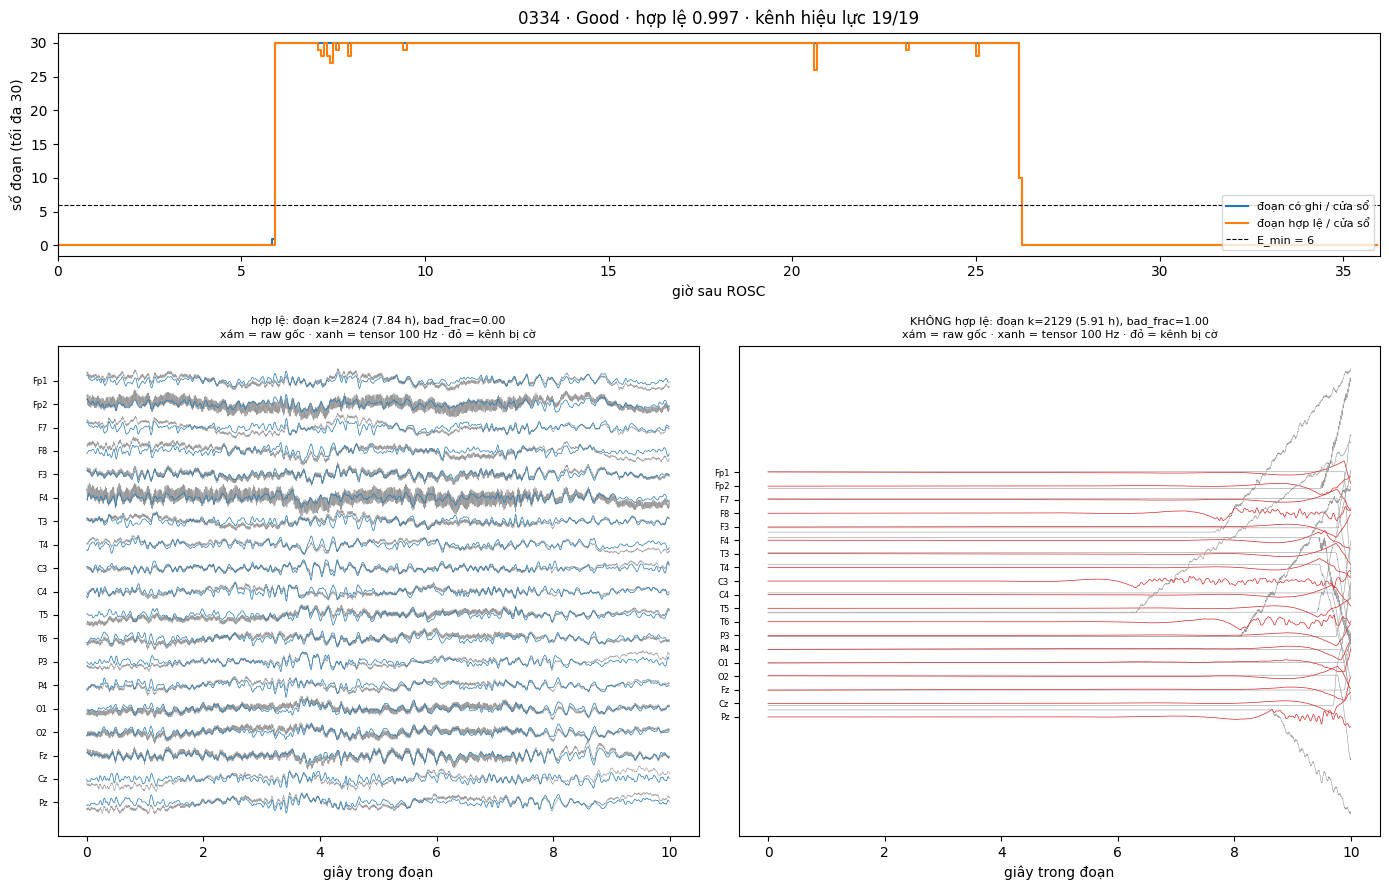

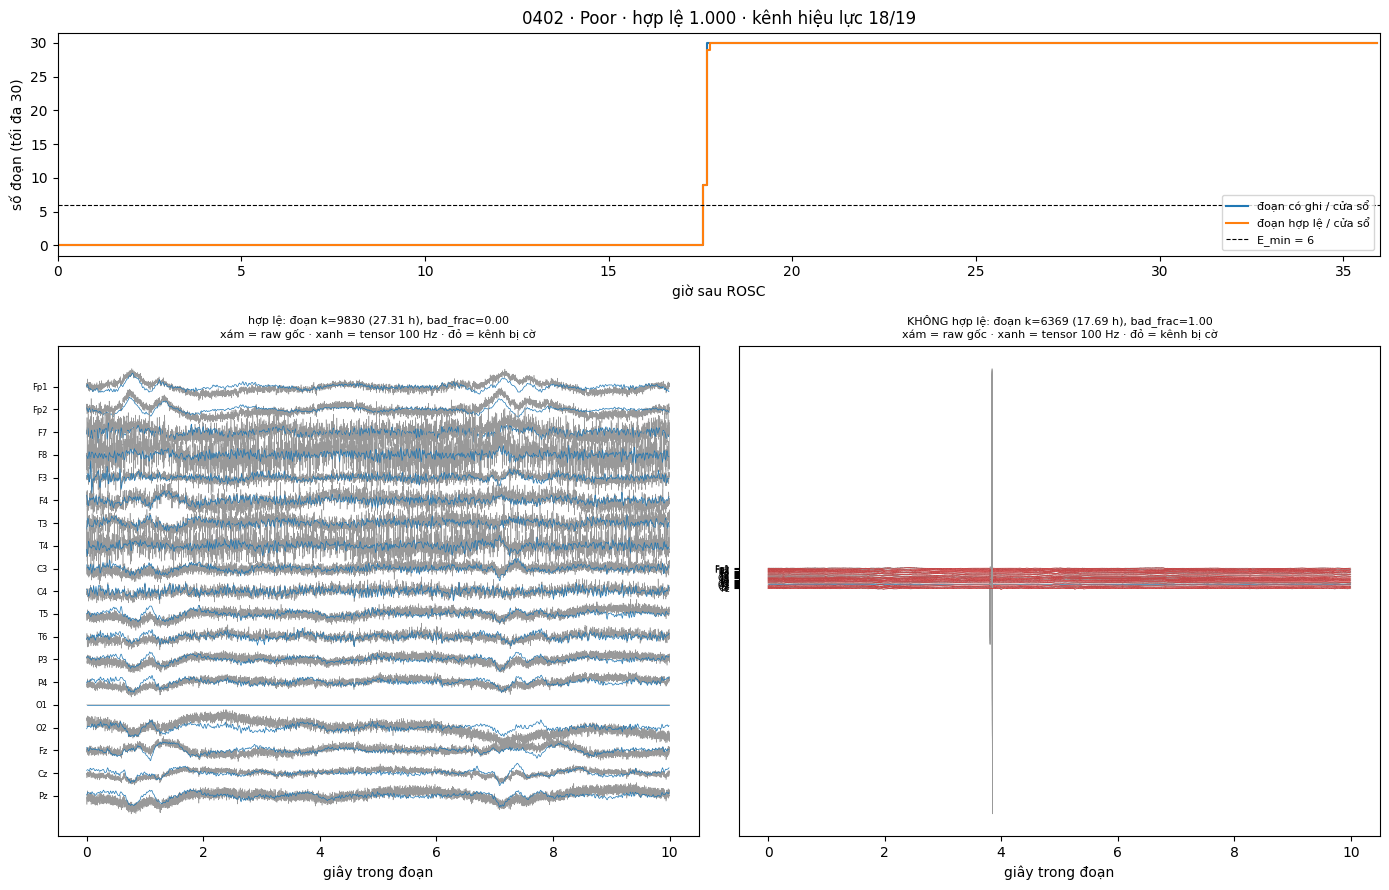

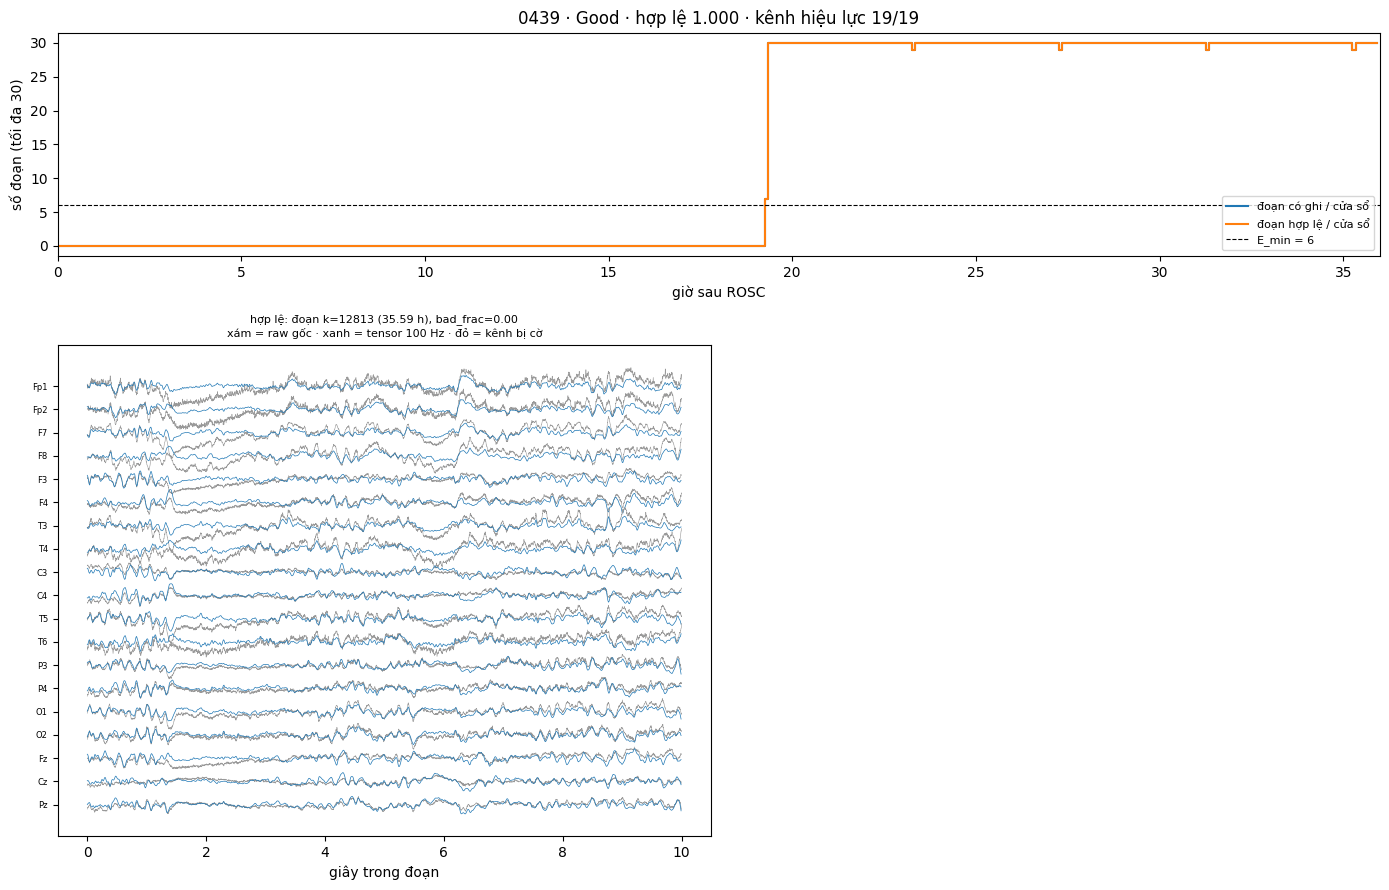

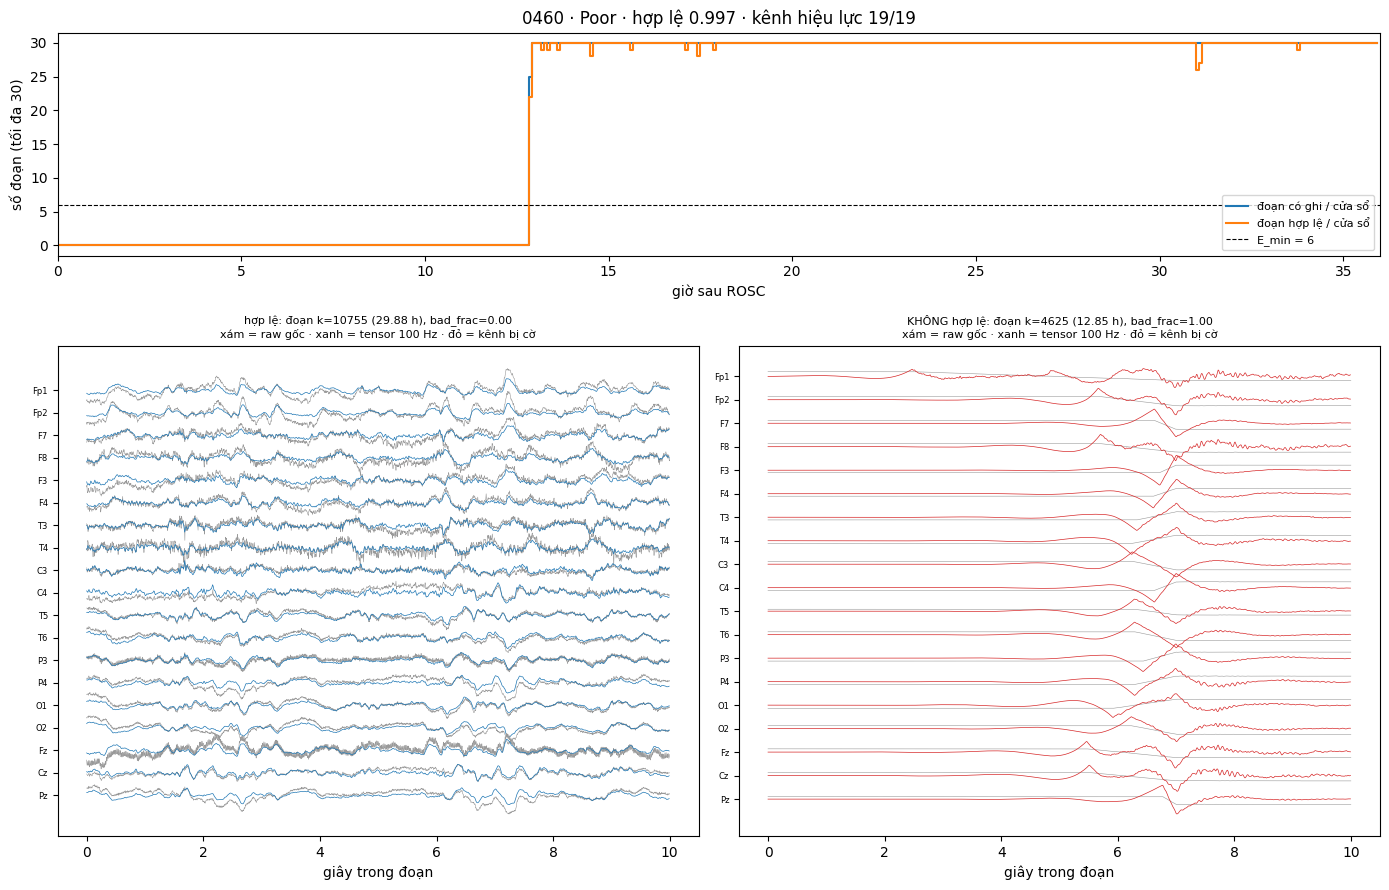

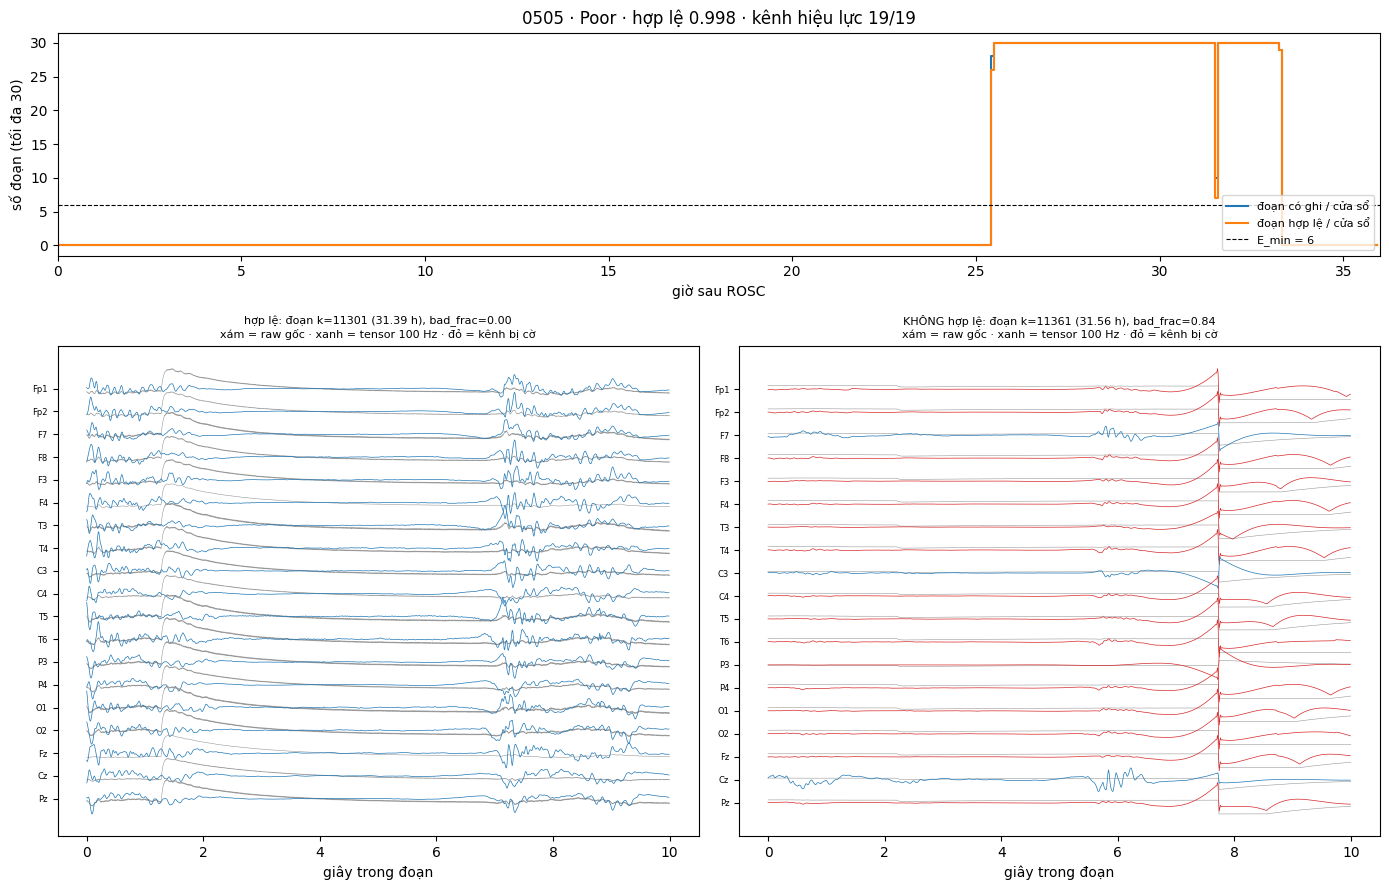

Đã lưu: ['0334_phase2_qc.png', '0402_phase2_qc.png', '0439_phase2_qc.png', '0460_phase2_qc.png', '0505_phase2_qc.png']


In [ ]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
QC_PIDS = sorted(rng.choice(sorted(D.patient_id), size=min(5, len(D)), replace=False).tolist())
reader = wfdb_block_reader(ctx.cfg1["paths"]["data_root"])
E, G = ctx.grid.e_win, ctx.grid

def raw_epoch(pid, k, si):
    s = ctx.specs[pid].segments[si]; fs = s["fs"]; L = int(round(G.epoch_sec * fs))
    i0 = int(round((k * G.epoch_sec - s["start_sec"]) * fs)); i0 = max(0, min(i0, s["n_samples"] - L))
    rb = reader(pid, s["record"], i0, i0 + L)
    mp = _map_channels(rb.sig_name, ctx.specs[pid].hp, ctx.canon)
    cols = [i for _, i in mp]
    x = (rb.d[:, cols].astype(float) - rb.base[cols]) / rb.gain[cols]
    return [c for c, _ in mp], x - x.mean(0), fs

for pid in QC_PIDS:
    d = PROC / pid; X = torch.load(d / "epochs.pt"); M = torch.load(d / "epoch_meta.pt")
    k = M["epoch_k"].numpy(); v = M["valid_epoch"].numpy()
    rec = np.zeros(G.n_ep, int); val = np.zeros(G.n_ep, int); rec[k] = 1; val[k[v]] = 1
    h = np.arange(G.w_max) * G.window_min / 60
    fig = plt.figure(figsize=(14, 9)); gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.2])
    ax = fig.add_subplot(gs[0, :])
    ax.step(h, rec.reshape(-1, E).sum(1), where="post", label="đoạn có ghi / cửa sổ")
    ax.step(h, val.reshape(-1, E).sum(1), where="post", label="đoạn hợp lệ / cửa sổ")
    ax.axhline(G.E_min, ls="--", c="k", lw=0.8, label=f"E_min = {G.E_min}")
    ax.set_xlim(0, G.horizon_h); ax.set_xlabel("giờ sau ROSC"); ax.set_ylabel("số đoạn (tối đa 30)")
    ax.set_title(f"{pid} · {ctx.specs[pid].labels['outcome']} · hợp lệ {v.mean():.3f} · kênh hiệu lực {int(ctx.specs[pid].eff_mask.sum())}/19")
    ax.legend(loc="lower right", fontsize=8)
    bad_idx = np.flatnonzero(~v)
    pick = [("hợp lệ", int(rng.choice(np.flatnonzero(v))))] if v.any() else []
    if len(bad_idx): pick.append(("KHÔNG hợp lệ", int(bad_idx[np.argmax(M["bad_frac"].numpy()[bad_idx])])))
    for j, (lab, i) in enumerate(pick[:2]):
        chans, xr, fs = raw_epoch(pid, int(k[i]), int(M["seg_index"][i]))
        a2 = fig.add_subplot(gs[1, j]); sc = np.nanmedian(np.abs(xr)) * 8 + 1e-9
        bad = M["bad_ch"][i].numpy()
        for c, name in enumerate(STD19):
            off = -c
            if name in chans:
                a2.plot(np.arange(xr.shape[0]) / fs, xr[:, chans.index(name)] / sc + off, lw=0.4, c="0.6")
            a2.plot(np.arange(1000) / 100, X[i, c].float().numpy() / 8 + off, lw=0.5, c="tab:red" if bad[c] else "tab:blue")
        a2.set_yticks(-np.arange(19)); a2.set_yticklabels(STD19, fontsize=6)
        a2.set_title(f"{lab}: đoạn k={int(k[i])} ({k[i] * 10 / 3600:.2f} h), bad_frac={float(M['bad_frac'][i]):.2f}\n"
                     "xám = raw gốc · xanh = tensor 100 Hz · đỏ = kênh bị cờ", fontsize=8)
        a2.set_xlabel("giây trong đoạn")
    fig.tight_layout(); fig.savefig(FIG2 / f"{pid}_phase2_qc.png", dpi=110); plt.show()
print("Đã lưu:", sorted(p.name for p in FIG2.glob("*_phase2_qc.png")))

In [ ]:
lines = [f"run_hash  {RUN_HASH}", f"preprocess_phase2.yaml  {sha256_file(ROOT / 'configs' / 'preprocess_phase2.yaml')}"]
lines += [f"phase1_{k}  {v}" for k, v in ctx.hashes.items()]
for pid in sorted(D.patient_id):
    lines.append(f"{pid}  " + hashlib.sha256((PROC / pid / "_DONE.json").read_bytes()).hexdigest())
(ROOT / "data" / "audit" / "data_hash_phase2.txt").write_text("\n".join(lines) + "\n")
DOD = {
    **CHK,
    "meta.json có n_valid_per_hour[36]": all(len(json.loads((PROC / p / "meta.json").read_text())["n_valid_per_hour"]) == 36 for p in D.patient_id),
    "hình QC 5 bệnh nhân": len(list(FIG2.glob("*_phase2_qc.png"))) >= min(5, len(D)),
    "data_hash_phase2.txt": (ROOT / "data" / "audit" / "data_hash_phase2.txt").exists(),
}
for k, v in DOD.items(): print("oke" if v else "NO ", k)
print(f"\nDone: {int(summ.done.sum())}/{len(summ)} | đoạn lưu: {int(D.n_epochs_stored.sum()):,} | đoạn hợp lệ: {int(D.n_epochs_valid.sum()):,}")
print("Đây là số liệu mô tả dữ liệu sau tiền xử lý, KHÔNG phải kết quả mô hình.")

NO  mọi bệnh nhân included đã xong
oke không lưu đoạn ngoài vùng ghi của Phase 1
oke không thiếu kênh hiệu lực trong segment
oke số cửa sổ (quy tắc Phase 1) = audit Phase 1
oke đặc trưng artifact trùng Phase 1 (max rel diff < 1e-9)
oke meta.json có n_valid_per_hour[36]
oke hình QC 5 bệnh nhân
oke data_hash_phase2.txt

Done: 153/289 | đoạn lưu: 1,130,183 | đoạn hợp lệ: 1,079,897
Đây là số liệu mô tả dữ liệu sau tiền xử lý, KHÔNG phải kết quả mô hình.
